# Non-Ideal Reactors - investigating backmixing in PFTRs



## Chemical Reaction Engineering 3 - Assignment 4

Group 4
- Julian Stierstorfer (1160552)
- Akshay Archak ()
- Girijasri Rajendran ()

# 1. Introduction

Ideal reactor models are important simplifications in chemical reaction engineering. They reduce the real flow and mixing behaviour of reactors to limiting cases that can be described with compact balance equations. For tubular reactors, the plug-flow tubular reactor (PFTR) assumes ideal convective transport in axial direction, no radial concentration or temperature gradients and no axial backmixing. Under these assumptions, all fluid elements move through the reactor with the same residence time, and the reactor can be modelled as an initial value problem along the reactor length.

In real reactors, these ideal assumptions are only approximations. Deviations can arise from velocity profiles, molecular diffusion, turbulent dispersion, entrance effects or local recirculation zones. One important form of non-ideal behaviour is axial backmixing, where material is transported opposite to the main flow direction. This broadens the residence time distribution and changes the local concentration profile compared to the ideal PFTR. As a result, the conversion can differ from the ideal plug-flow prediction.

In this study, a tubular reactor with a length of $L = 10~\mathrm{m}$ and a diameter of $d_{\mathrm{R}} = 32~\mathrm{mm}$ is investigated. The reactor is fed from an upstream section with a diameter of $d_0 = 150~\mathrm{mm}$. The volumetric flow rate is $\dot{V} = 1~\mathrm{L,s^{-1}}$, and the feed contains component $\mathrm{A}$ with an inlet concentration of $c_{\mathrm{A},0} = 100~\mathrm{mol,m^{-3}}$.

The investigated reaction is assumed to be an irreversible reaction from component $\mathrm{A}$ to component $\mathrm{B}$.

\begin{equation}
\mathrm{A} \rightarrow \mathrm{B}
\tag{1}
\end{equation}

This study investigates the influence of axial backmixing in tubular reactors for this simplified reaction system. The ideal PFTR is first used as the reference case without axial dispersion. Non-ideal behaviour is then introduced using the axial dispersion model, where the degree of backmixing is described by the Bodenstein number. High Bodenstein numbers correspond to weak dispersion and approach ideal plug-flow behaviour, while low Bodenstein numbers represent stronger backmixing and increasingly mixed-flow characteristics.

In addition, a CSTR cascade is implemented as an alternative representation of non-ideal tubular reactor behaviour. By increasing the number of ideally mixed tanks, the cascade approaches plug-flow behaviour, whereas a small number of tanks represents stronger mixing. The comparison between the ideal PFTR, the axial dispersion model and the CSTR cascade is used to evaluate how backmixing influences concentration profiles, outlet conversion and the transition between ideal and non-ideal reactor behaviour.

# 2. Theoretical Background: Ideal and Non-Ideal PFTRs

## 2.1 Ideal PFTR

The ideal PFTR is used as the limiting case without axial backmixing. The reactor is described by a one-dimensional steady-state material balance along the reactor coordinate $z$. The reaction is assumed to be irreversible and follows a power-law rate expression with respect to component $\mathrm{A}$. For first-order kinetics, the reaction order is set to $n=1$, but the following equations are written for a general reaction order $n$.

Main assumptions:

* steady-state operation
* one-dimensional flow in axial direction
* constant superficial velocity $u$
* constant density and reactor cross-section
* no radial concentration gradients
* no axial dispersion or backmixing
* isothermal operation with constant rate constant $k$
* irreversible reaction $\mathrm{A} \rightarrow \mathrm{B}$
* power-law kinetics with reaction order $n$

For the reaction rate,

\begin{equation}
r = k c_{\mathrm{A}}^{n}
\tag{2}
\end{equation}

the steady-state component balances are:

\begin{equation}
u \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} = -r
\qquad
u \frac{\mathrm{d} c_{\mathrm{B}}}{\mathrm{d} z} = r
\tag{3}
\end{equation}

With Eq. (2), the balance for component $\mathrm{A}$ becomes:

\begin{equation}
\frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} = -\frac{k}{u} c_{\mathrm{A}}^{n}
\tag{4}
\end{equation}

The initial conditions are defined at the reactor inlet:

\begin{equation}
c_{\mathrm{A}}(0) = c_{\mathrm{A},0}
\qquad
c_{\mathrm{B}}(0) = c_{\mathrm{B},0}
\tag{5}
\end{equation}

The conversion of component $\mathrm{A}$ is calculated from the outlet concentration:

\begin{equation}
X_{\mathrm{A}} = 1 - \frac{c_{\mathrm{A}}(L)}{c_{\mathrm{A},0}}
\tag{6}
\end{equation}

The ideal PFTR model is therefore an initial value problem. Since axial dispersion is neglected, the inlet concentration directly fixes the concentration profile along the reactor length.

## 2.2 Non-Ideal PFTR with Axial Dispersion

Real tubular reactors can deviate from ideal plug-flow behaviour because fluid elements do not necessarily move through the reactor with one identical residence time. Axial dispersion is used to describe this non-ideal behaviour by adding a dispersion term to the convective material balance. This term represents axial backmixing and is mathematically analogous to diffusive transport in the axial direction.

Main assumptions:

* steady-state operation
* one-dimensional axial reactor model
* constant reactor cross-section $A$
* constant superficial velocity $u$ inside the reactor
* constant axial dispersion coefficient $\mathcal{D}$
* no radial concentration gradients
* isothermal operation with constant rate constant $k$
* irreversible reaction $\mathrm{A} \rightarrow \mathrm{B}$
* power-law kinetics with reaction order $n$
* axial backmixing represented by the dispersion term

For a general component $i$, the steady-state material balance with axial dispersion is:

\begin{equation}
u \frac{\mathrm{d} c_i}{\mathrm{d} z} = \mathcal{D} \frac{\mathrm{d}^2 c_i}{\mathrm{d} z^2} + \sum_{j=1}^{M} \nu_{i,j} r_j
\tag{7}
\end{equation}

For the investigated reaction, Eq. (7) gives the component balances for $\mathrm{A}$ and $\mathrm{B}$:

\begin{equation}
\mathcal{D} \frac{\mathrm{d}^{2} c_{\mathrm{A}}}{\mathrm{d} z^{2}} - u \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} - r = 0
\qquad
\mathcal{D} \frac{\mathrm{d}^{2} c_{\mathrm{B}}}{\mathrm{d} z^{2}} - u \frac{\mathrm{d} c_{\mathrm{B}}}{\mathrm{d} z} + r = 0
\tag{8}
\end{equation}

With the power-law rate expression from Eq. (2), the balance for component $\mathrm{A}$ becomes:

\begin{equation}
\mathcal{D} \frac{\mathrm{d}^{2} c_{\mathrm{A}}}{\mathrm{d} z^{2}} - u \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} - k c_{\mathrm{A}}^{n} = 0
\tag{9}
\end{equation}

In contrast to the ideal PFTR, the axial dispersion model contains second-order spatial derivatives. Therefore, the reactor cannot be solved as an initial value problem with inlet concentrations only. Boundary conditions are required at both reactor ends. This is physically necessary because the concentration at the reactor inlet is influenced by backmixing from downstream positions. Therefore, the concentration directly at $z=0$ is not necessarily equal to the upstream feed concentration.

At the inlet, the Danckwerts boundary condition is formulated as a molar flux balance across the reactor boundary. The molar flow entering from the upstream section must be equal to the sum of convective and dispersive molar transport at the reactor inlet:

\begin{equation}
z = 0: \qquad u_0 A_0 c_{i,0} = u A c_i(0) - A \mathcal{D} \left.\frac{\mathrm{d} c_i}{\mathrm{d} z}\right|_{z=0}
\qquad i = \mathrm{A}, \mathrm{B}
\tag{10}
\end{equation}

Here, $u_0$, $A_0$ and $c_{i,0}$ describe the velocity, cross-sectional area and concentration in the upstream feed section. The corresponding reactor quantities are $u$, $A$ and $c_i(0)$ at the reactor inlet. The term $u A c_i(0)$ describes convective transport into the reactor, while $-A \mathcal{D} \mathrm{d}c_i/\mathrm{d}z$ describes axial dispersive transport. This formulation allows $c_i(0)$ to differ from the upstream feed concentration $c_{i,0}$.

For constant volumetric flow rate,

\begin{equation}
\dot{V} = u_0 A_0 = u A
\tag{11}
\end{equation}

Eq. (10) can be written as:

\begin{equation}
z = 0: \qquad \dot{V} c_{i,0} = \dot{V} c_i(0) - A \mathcal{D} \left.\frac{\mathrm{d} c_i}{\mathrm{d} z}\right|_{z=0}
\qquad i = \mathrm{A}, \mathrm{B}
\tag{12}
\end{equation}

If the upstream section and the reactor have the same cross-sectional area and velocity, Eq. (10) further simplifies to:

\begin{equation}
z = 0: \qquad u \left(c_{i,0} - c_i(0)\right) = -\mathcal{D} \left.\frac{\mathrm{d} c_i}{\mathrm{d} z}\right|_{z=0}
\qquad i = \mathrm{A}, \mathrm{B}
\tag{13}
\end{equation}

This simplified inlet condition shows the role of backmixing directly. The difference between the upstream feed concentration and the concentration at the reactor inlet is balanced by the dispersive flux. If axial dispersion becomes negligible, the gradient term vanishes and the ideal PFTR inlet condition $c_i(0) = c_{i,0}$ is recovered.

At the outlet, the Danckwerts boundary condition is given by a zero-gradient condition:

\begin{equation}
z = L: \qquad \left.\frac{\mathrm{d} c_i}{\mathrm{d} z}\right|_{z=L} = 0
\qquad i = \mathrm{A}, \mathrm{B}
\tag{14}
\end{equation}

This condition assumes that no additional axial concentration change is imposed downstream of the reactor. The concentration profile is therefore forced to become flat at the reactor outlet. Together, Eqs. (10) and (14) close the boundary value problem for each component.

The strength of axial backmixing is described by the Bodenstein number:

\begin{equation}
Bo = \frac{u L}{\mathcal{D}}
\tag{15}
\end{equation}

The Bodenstein number compares convective transport with axial dispersion. High values of $Bo$ correspond to weak axial dispersion and approach ideal PFTR behaviour. Low values of $Bo$ correspond to stronger axial backmixing and broader residence time distributions. Therefore, the axial dispersion model is used to investigate the transition from ideal plug-flow behaviour to increasingly non-ideal reactor behaviour.

Mathematically, this distinction means that the ideal PFTR is formulated as an initial value problem, while the non-ideal PFTR with axial dispersion is formulated as a boundary value problem.

## 2.3 Residence Time Distribution of Ideal and Non-Ideal PFTRs

The residence time distribution describes how long fluid elements remain inside the reactor. For an ideal PFTR, plug-flow behaviour is assumed. This means that all fluid elements move through the reactor with the same residence time. Therefore, the cumulative distribution function is a step function at the mean residence time.

\begin{equation}
F(t) = H(t-\tau) =
\left\{
\begin{array}{ll}
1, & t > \tau \\
0, & t < \tau
\end{array}
\right.
\tag{16}
\end{equation}

Here, $\tau$ is the residence time and $H(t-\tau)$ is the Heaviside step function shifted by the residence time. Eq. (16) expresses that all fluid elements leave the ideal PFTR at the same time. Therefore, the RTD of an ideal PFTR is infinitely narrow.

Real tubular reactors can deviate from this ideal behaviour. One reason is the influence of viscous forces on the velocity profile. In laminar pipe flow, the velocity is not constant over the reactor radius, but follows a parabolic profile:

\begin{equation}
u(r) = 2 \bar{u} \left[ 1 - \left(\frac{r}{R}\right)^2 \right]
\tag{17}
\end{equation}

Here, $u(r)$ is the local velocity, $\bar{u}$ is the mean velocity, $r$ is the radial position and $R$ is the reactor radius. Since the fluid close to the wall moves more slowly than the fluid in the centre, fluid elements have different residence times. For laminar flow, the cumulative distribution function can be written as:

\begin{equation}
F(t) = 1 - \frac{1}{4} \left(\frac{\bar{t}}{t}\right)^2
\tag{18}
\end{equation}

with the mean residence time:

\begin{equation}
\bar{t} = \frac{L}{\bar{u}} = \bar{\tau}
\tag{19}
\end{equation}

Compared to the ideal PFTR, Eq. (18) does not describe an instant step. Instead, the residence times are distributed because different fluid elements move with different velocities. Consequently, some fluid elements leave the reactor earlier than the mean residence time, while others remain inside the reactor for a longer time and leave later.

For the axial dispersion model, the cumulative distribution function changes from the ideal step function to a continuous function. This represents the effect of backmixing in the reactor. The corresponding differential representation of the cumulative distribution function is the residence time distribution $E(\Theta)$, with the dimensionless time $\Theta = t / \bar{t}$.

\begin{equation}
\int_{-\infty}^{+\infty} E(\Theta) \ \mathrm{d}\Theta = 1
\tag{20}
\end{equation}

The RTD for the dispersion model can be expressed using the Bodenstein number:

\begin{equation}
E(\Theta) = \frac{1}{\sqrt{4 \pi / Bo}} \exp \left[-\frac{(1-\Theta)^2}{4 / Bo}\right]
\tag{21}
\end{equation}

The Bodenstein number therefore links the RTD to the strength of axial dispersion. A high $Bo$ value corresponds to weak dispersion and gives a sharper RTD, which approaches ideal plug-flow behaviour. A lower $Bo$ value corresponds to stronger dispersion and therefore a broader RTD. Thus, the ideal PFTR is represented by an instantaneous residence time, while the non-ideal PFTR is represented by a distributed residence time caused by non-ideal flow and backmixing.

## 2.4 Reaction System

The investigated reactor and reaction system are summarized in Table 1.

<p align="left"><strong>Table 1:</strong> Reactor and reaction system used for the numerical investigation.</p>

| Quantity | Symbol | Value |
|---|---:|---:|
| Reactor length | $L$ | $10~\mathrm{m}$ |
| Reactor diameter | $d_{\mathrm{R}}$ | $32~\mathrm{mm}$ |
| Upstream inlet diameter | $d_0$ | $150~\mathrm{mm}$ |
| Volumetric flow rate | $\dot{V}$ | $1~\mathrm{L,s^{-1}}$ |
| Feed concentration of $\mathrm{A}$ | $c_{\mathrm{A},0}$ | $100~\mathrm{mol,m^{-3}}$ |
| Feed concentration of $\mathrm{B}$ | $c_{\mathrm{B},0}$ | $0~\mathrm{mol,m^{-3}}$ |
| Reaction rate constant | $k$ | varied |
| Dispersion coefficient | $\mathcal{D}$ | varied |
| Bodenstein number | $Bo$ | varied |
| Reaction type | - | first-order, irreversible |

## 2.5 Importing packages and parameters

First, all needed packages for calculation, numerical solution and data visualisation is imported:

In [69]:
# importing packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import root

Then, important import parameters are defined. In this case a reaction order of 1, as well as a reaction rate constant of $1\; \mathrm{s^{-1}}$ is assumed. A Bodenstein number of $Bo = 50$ is used as the first non-ideal reference case. This value represents moderate axial dispersion, because convective transport is still dominant while axial backmixing is already large enough to cause visible deviations from ideal plug-flow behaviour.

Thus, high $Bo$ values approach the ideal PFTR limit, while lower $Bo$ values represent stronger axial dispersion. Therefore, $Bo = 50$ is suitable for the first comparison between the ideal PFTR and the non-ideal dispersion model.

In [70]:
# input parameters
L = 10.0                         # reactor length, m
D = 32e-3                        # reactor diameter, m
D_upstream = 150e-3              # upstream inlet diameter, m
V_dot = 0.001                    # volumetric flow rate, m^3 s^-1
c_A_in = 100.0                   # inlet concentration A, mol m^-3
c_in = np.array([c_A_in, 0.0])    # inlet concentration vector [A, B], mol m^-3
stoich_coeff = np.array([-1, 1]) # stoichiometric coefficients for A -> B, -
k = 1.0                          # rate constant, unit depends on n
n = 1.0                          # reaction order, -
Bo = 50.0                        # Bodenstein number, -

The reactor and flow parameters are calculated from the previously defined input values. First, the reactor and upstream cross-sectional areas are determined from the corresponding diameters. The reactor volume is then calculated from the reactor area and length.

Using the volumetric flow rate, the superficial velocities in the reactor and in the upstream section are calculated. These velocities are required because the Danckwerts inlet boundary condition distinguishes between upstream and reactor quantities. The space time $\tau$ describes the nominal residence time in the reactor, while the axial dispersion coefficient is calculated from the selected Bodenstein number.

\begin{equation}
\mathcal{D} = \frac{uL}{Bo}
\tag{32}
\end{equation}

The arrays `z_eval` and `z_mesh` define the axial positions used for evaluating and solving the numerical models. The tolerances `rtol_ivp`, `atol_ivp`, `tol_bvp` and `max_nodes_bvp` specify the numerical accuracy settings for the IVP and BVP solvers. This can be adapted in case of convergence problems of the numerical solver.

In [71]:
# reactor and flow parameters
A = np.pi * D**2 / 4             # reactor cross-sectional area, m^2
A_0 = np.pi * D_upstream**2 / 4  # upstream cross-sectional area, m^2
V = A * L                        # reactor volume, m^3

u = V_dot / A                    # superficial velocity in reactor, m s^-1
u_0 = V_dot / A_0                # upstream superficial velocity, m s^-1

tau = L / u                      # space time, s
D_ax = u * L / Bo                # axial dispersion coefficient, m^2 s^-1

z_eval = np.linspace(0.0, L, 300)
z_mesh = np.linspace(0.0, L, 250)

rtol_ivp = 1e-8
atol_ivp = 1e-10

tol_bvp = 1e-5
max_nodes_bvp = 10000

print(f"A = {A:.4e} m^2")
print(f"V = {V:.4e} m^3")
print(f"u = {u:.4f} m s^-1")
print(f"u_0 = {u_0:.4f} m s^-1")
print(f"tau = {tau:.4f} s")
print(f"D_ax = {D_ax:.4e} m^2 s^-1")

A = 8.0425e-04 m^2
V = 8.0425e-03 m^3
u = 1.2434 m s^-1
u_0 = 0.0566 m s^-1
tau = 8.0425 s
D_ax = 2.4868e-01 m^2 s^-1


## 3.1 Ideal PFTR implementation

To investigate the ideal reactor behaviour, the PFTR model is implemented in the function `pftr`. This function contains the component balances for the irreversible reaction $\mathrm{A} \rightarrow \mathrm{B}$ with power-law kinetics. The reaction order $n$ can be varied in the implementation. For the investigated first-order case, $n=1$ is used.

The state vector is defined as:

\begin{equation}
\mathbf{y} =
\begin{bmatrix}
c_{\mathrm{A}} \\
c_{\mathrm{B}}
\end{bmatrix}
\tag{22}
\end{equation}

Using the rate expression $r = k c_{\mathrm{A}}^{n}$, the implemented balance equations are:

\begin{equation}
\frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} = -\frac{k}{u} c_{\mathrm{A}}^{n}
\qquad
\frac{\mathrm{d} c_{\mathrm{B}}}{\mathrm{d} z} = \frac{k}{u} c_{\mathrm{A}}^{n}
\tag{23}
\end{equation}

The initial conditions are given by the feed concentrations at the reactor inlet:

\begin{equation}
c_{\mathrm{A}}(0) = c_{\mathrm{A},0}
\qquad
c_{\mathrm{B}}(0) = c_{\mathrm{B},0}
\tag{24}
\end{equation}

Since only inlet values are required, the ideal PFTR is solved as an initial value problem. The outlet conversion is calculated from the final value of $c_{\mathrm{A}}$:

\begin{equation}
X_{\mathrm{A}} = 1 - \frac{c_{\mathrm{A}}(L)}{c_{\mathrm{A},0}}
\tag{25}
\end{equation}

In [72]:
def reaction_rate(c_A, k, n):
    """
    Calculate the reaction rate for the power-law reaction A -> B.

    Inputs
    ------
    c_A : float or np.ndarray
        Concentration of reactant A, mol m^-3.
    k : float
        Reaction rate constant. Unit depends on reaction order n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.

    Output
    ------
    r : float or np.ndarray
        Reaction rate, mol m^-3 s^-1.
    """
    c_A_physical = np.maximum(c_A, 0.0)   # avoids non-physical negative rates
    r = k * c_A_physical**n              # reaction rate, mol m^-3 s^-1

    return r


def pftr_model(z, c, k, n, stoich_coeff, u):
    """
    Define the ideal PFTR model for the reaction A -> B.

    Inputs
    ------
    z : float
        Axial reactor coordinate, m.
    c : np.ndarray
        Concentration vector [c_A, c_B], mol m^-3.
    k : float
        Reaction rate constant. Unit depends on reaction order n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.
    stoich_coeff : np.ndarray
        Stoichiometric coefficient vector [nu_A, nu_B], -.
    u : float
        Superficial velocity in the reactor, m s^-1.

    Output
    ------
    dc_dz : np.ndarray
        Axial concentration gradients [dc_A/dz, dc_B/dz], mol m^-4.
    """
    c_A = c[0]                            # concentration of A, mol m^-3

    r = reaction_rate(c_A, k, n)          # reaction rate, mol m^-3 s^-1
    dc_dz = stoich_coeff * r / u         # concentration gradient, mol m^-4

    return dc_dz


sol_pftr = solve_ivp(
    fun=pftr_model,
    t_span=(0.0, L),
    y0=c_in,
    args=(k, n, stoich_coeff, u),
    t_eval=z_eval,
    method="RK45",
    rtol=rtol_ivp,
    atol=atol_ivp,
)

if not sol_pftr.success:
    raise RuntimeError(sol_pftr.message)

z_pftr = sol_pftr.t                       # axial coordinates, m
c_pftr = sol_pftr.y                       # concentration profiles, mol m^-3

c_A_pftr = c_pftr[0]                      # concentration profile of A, mol m^-3
c_B_pftr = c_pftr[1]                      # concentration profile of B, mol m^-3

X_A_pftr = 1.0 - c_A_pftr[-1] / c_A_in    # outlet conversion of A, -

print(f"PFTR outlet conversion: X_A = {X_A_pftr:.5f}")
print(f"PFTR outlet c_A = {c_A_pftr[-1]:.5f} mol m^-3")
print(f"PFTR outlet c_B = {c_B_pftr[-1]:.5f} mol m^-3")

PFTR outlet conversion: X_A = 0.99968
PFTR outlet c_A = 0.03215 mol m^-3
PFTR outlet c_B = 99.96785 mol m^-3


## 3.2 Non-ideal PFTR implementation with axial dispersion

The non-ideal PFTR is implemented using the axial dispersion model. The model is split into two functions. The function `dispersion_model` contains the differential equations, while the function `dispersion_boundary_conditions` contains the Danckwerts boundary conditions at the inlet and outlet.

The second-order dispersion balances from Eq. (7) are rewritten as a system of first-order differential equations. For the irreversible reaction $\mathrm{A} \rightarrow \mathrm{B}$ with power-law kinetics, the second-order balances are:

\begin{equation}
\mathcal{D} \frac{\mathrm{d}^{2} c_{\mathrm{A}}}{\mathrm{d} z^{2}} - u \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} - k c_{\mathrm{A}}^{n} = 0
\qquad
\mathcal{D} \frac{\mathrm{d}^{2} c_{\mathrm{B}}}{\mathrm{d} z^{2}} - u \frac{\mathrm{d} c_{\mathrm{B}}}{\mathrm{d} z} + k c_{\mathrm{A}}^{n} = 0
\tag{26}
\end{equation}

The state vector for the boundary value problem is defined as:

\begin{equation}
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
y_4
\end{bmatrix}
=
\begin{bmatrix}
c_{\mathrm{A}} \\
\frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d} z} \\
c_{\mathrm{B}} \\
\frac{\mathrm{d} c_{\mathrm{B}}}{\mathrm{d} z}
\end{bmatrix}
\tag{27}
\end{equation}

This gives the following first-order system implemented in `dispersion_model`:

\begin{equation}
\frac{\mathrm{d} y_1}{\mathrm{d} z} = y_2
\qquad
\frac{\mathrm{d} y_2}{\mathrm{d} z} = \frac{u y_2 + k y_1^{n}}{\mathcal{D}}
\tag{28}
\end{equation}

\begin{equation}
\frac{\mathrm{d} y_3}{\mathrm{d} z} = y_4
\qquad
\frac{\mathrm{d} y_4}{\mathrm{d} z} = \frac{u y_4 - k y_1^{n}}{\mathcal{D}}
\tag{29}
\end{equation}

The function `dispersion_boundary_conditions` applies the Danckwerts inlet condition and the zero-gradient outlet condition. At the inlet, the upstream molar flow is balanced with the convective and dispersive transport at the reactor boundary:

\begin{equation}
u_0 A_0 c_{i,0}
=
u A c_i(0)
-
A \mathcal{D}
\left.
\frac{\mathrm{d} c_i}{\mathrm{d} z}
\right|_{z=0}
\qquad
i = \mathrm{A}, \mathrm{B}
\tag{30}
\end{equation}

At the outlet, the axial concentration gradient is set to zero:

\begin{equation}
\left.
\frac{\mathrm{d} c_i}{\mathrm{d} z}
\right|_{z=L}
= 0
\qquad
i = \mathrm{A}, \mathrm{B}
\tag{31}
\end{equation}

Since the dispersion model is solved with `solve_bvp`, an initial guess for the complete state vector has to be provided on the numerical mesh. This initial guess is not a physical boundary condition, but only a starting profile for the iterative BVP solver. To keep the implementation simple and physically reasonable, constant concentration profiles are used as initial guesses. The reactant concentration is initialized with the feed concentration, the product concentration with the product feed concentration, and both concentration gradients are initialized with zero:

\begin{equation}
\mathbf{y}_{\mathrm{guess}}(z) =
\begin{bmatrix}
c_{\mathrm{A},0} \\
0 \\
c_{\mathrm{B},0} \\
0
\end{bmatrix}
\tag{32}
\end{equation}

This choice is more physical than a complete zero initialization, because the feed contains component $\mathrm{A}$. At the same time, it keeps the implementation independent of the ideal PFTR solution and avoids using the PFTR result as a numerical pre-solution for the dispersion model.

The dispersion model is therefore solved as a boundary value problem. In contrast to the ideal PFTR, the concentration at the reactor inlet is part of the solution and does not have to be identical to the upstream feed concentration. For the investigated first-order case, the reaction order is set to $n=1$ in the implementation.

In [73]:
def dispersion_model(z, y, k, n, stoich_coeff, u, D_ax):
    """
    Define the axial dispersion model as a first-order differential equation system.

    State vector
    ------------
    y[0] = c_A
        Concentration of reactant A, mol m^-3.
    y[1] = dc_A/dz
        Axial concentration gradient of A, mol m^-4.
    y[2] = c_B
        Concentration of product B, mol m^-3.
    y[3] = dc_B/dz
        Axial concentration gradient of B, mol m^-4.

    Inputs
    ------
    z : float or np.ndarray
        Axial reactor coordinate, m.
    y : np.ndarray
        State matrix with shape (4, len(z)) for solve_bvp.
    k : float
        Reaction rate constant. Unit depends on n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.
    stoich_coeff : np.ndarray
        Stoichiometric coefficient vector [nu_A, nu_B], -.
    u : float
        Superficial velocity in the reactor, m s^-1.
    D_ax : float
        Axial dispersion coefficient, m^2 s^-1.

    Output
    ------
    dy_dz : np.ndarray
        Derivatives of the state vector with shape (4, len(z)).
    """
    c_A = y[0]                            # concentration of A, mol m^-3
    dc_A_dz = y[1]                        # concentration gradient of A, mol m^-4
    dc_B_dz = y[3]                        # concentration gradient of B, mol m^-4

    r = reaction_rate(c_A, k, n)          # reaction rate, mol m^-3 s^-1

    d2c_A_dz2 = (u * dc_A_dz - stoich_coeff[0] * r) / D_ax
    d2c_B_dz2 = (u * dc_B_dz - stoich_coeff[1] * r) / D_ax

    dy_dz = np.vstack((dc_A_dz, d2c_A_dz2, dc_B_dz, d2c_B_dz2))

    return dy_dz


def dispersion_boundary_conditions(ya, yb, c_in, u_0, A_0, u, A, D_ax):
    """
    Define Danckwerts boundary conditions for the axial dispersion model.

    Inputs
    ------
    ya : np.ndarray
        State vector at reactor inlet z = 0.
    yb : np.ndarray
        State vector at reactor outlet z = L.
    c_in : np.ndarray
        Inlet concentration vector [c_A,in, c_B,in], mol m^-3.
    u_0 : float
        Upstream superficial velocity, m s^-1.
    A_0 : float
        Upstream cross-sectional area, m^2.
    u : float
        Superficial velocity in the reactor, m s^-1.
    A : float
        Reactor cross-sectional area, m^2.
    D_ax : float
        Axial dispersion coefficient, m^2 s^-1.

    Output
    ------
    bc : np.ndarray
        Residuals of the four boundary conditions.
    """
    bc_A_in = u_0 * A_0 * c_in[0] - (u * A * ya[0] - A * D_ax * ya[1])
    bc_B_in = u_0 * A_0 * c_in[1] - (u * A * ya[2] - A * D_ax * ya[3])

    bc_A_out = yb[1]                      # dc_A/dz = 0 at z = L
    bc_B_out = yb[3]                      # dc_B/dz = 0 at z = L

    bc = np.array([bc_A_in, bc_B_in, bc_A_out, bc_B_out])

    return bc


# Physical initial guess for the BVP solver
y_guess = np.zeros((4, z_mesh.size))
y_guess[0, :] = c_in[0]                  # initial guess for c_A, mol m^-3
y_guess[1, :] = 0.0                      # initial guess for dc_A/dz, mol m^-4
y_guess[2, :] = c_in[1]                  # initial guess for c_B, mol m^-3
y_guess[3, :] = 0.0                      # initial guess for dc_B/dz, mol m^-4

# Boundary value problem
sol_disp = solve_bvp(
    fun=lambda z, y: dispersion_model(z, y, k, n, stoich_coeff, u, D_ax),
    bc=lambda ya, yb: dispersion_boundary_conditions(ya, yb, c_in, u_0, A_0, u, A, D_ax),
    x=z_mesh,
    y=y_guess,
    tol=tol_bvp,
    max_nodes=max_nodes_bvp,
)

if not sol_disp.success:
    raise RuntimeError(sol_disp.message)

# Results on common evaluation grid
z_disp = z_eval                          # axial coordinate, m
y_disp = sol_disp.sol(z_disp)            # evaluated BVP solution

c_A_disp = y_disp[0]                     # concentration profile of A, mol m^-3
dc_A_dz_disp = y_disp[1]                 # concentration gradient of A, mol m^-4
c_B_disp = y_disp[2]                     # concentration profile of B, mol m^-3
dc_B_dz_disp = y_disp[3]                 # concentration gradient of B, mol m^-4

X_A_disp = 1.0 - c_A_disp[-1] / c_in[0]  # outlet conversion of A, -

print(f"Dispersion model outlet conversion: X_A = {X_A_disp:.5f}")
print(f"Dispersion model inlet c_A = {c_A_disp[0]:.5f} mol m^-3")
print(f"Dispersion model outlet c_A = {c_A_disp[-1]:.5f} mol m^-3")
print(f"Dispersion model outlet c_B = {c_B_disp[-1]:.5f} mol m^-3")
print(f"BVP iterations = {sol_disp.niter}")
print(f"BVP mesh nodes = {sol_disp.x.size}")

Dispersion model outlet conversion: X_A = 0.99914
Dispersion model inlet c_A = 87.64430 mol m^-3
Dispersion model outlet c_A = 0.08552 mol m^-3
Dispersion model outlet c_B = 99.91448 mol m^-3
BVP iterations = 2
BVP mesh nodes = 254


## 3.3 CSTR Cascade Implementation

A CSTR cascade is implemented as an additional model for non-ideal reactor behaviour. The cascade consists of $N$ ideally mixed tanks in series. For $N = 1$, the system corresponds to one ideal CSTR with strong backmixing. With increasing $N$, the degree of backmixing decreases and the cascade approaches ideal PFTR behaviour.

The total space time is divided equally between all tanks:

\begin{equation}
\tau_N = \frac{\tau}{N}
\tag{33}
\end{equation}

For each tank $m$, the steady-state component balance is:

\begin{equation}
0 = c_{i,m-1} - c_{i,m} + \tau_N \nu_i k c_{\mathrm{A},m}^{n}
\qquad i = \mathrm{A}, \mathrm{B}
\tag{34}
\end{equation}

The outlet concentration of one tank is used as the inlet concentration of the next tank. After the last tank, the outlet conversion is calculated as:

\begin{equation}
X_{\mathrm{A},N} = 1 - \frac{c_{\mathrm{A},N}}{c_{\mathrm{A},0}}
\tag{35}
\end{equation}

The number of tanks $N$ is therefore used as the parameter controlling the transition from mixed-flow behaviour to ideal plug-flow behaviour.

For the $\mathrm{CSTR}$-cascade, the number of included vessels as well as the residence time for the $\mathrm{PFTR}$ and the space-time of one vessel inside the cascade is defined:

In [74]:
# CSTR cascade parameters

N_CSTR = 10                       # number of ideal CSTRs in cascade, -

tau_PFTR = V / V_dot              # PFTR space time, s
tau_CSTR = tau_PFTR / N_CSTR      # space time of one CSTR vessel, s

V_CSTR = V / N_CSTR               # volume of one CSTR vessel, m^3

print(f"N_CSTR = {N_CSTR:d}")
print(f"tau_PFTR = {tau_PFTR:.4f} s")
print(f"tau_CSTR = {tau_CSTR:.4f} s")
print(f"V_CSTR = {V_CSTR:.4e} m^3")

N_CSTR = 10
tau_PFTR = 8.0425 s
tau_CSTR = 0.8042 s
V_CSTR = 8.0425e-04 m^3


For reaction orders different from $n=1$, the CSTR balance becomes nonlinear in the outlet concentration of each tank. Therefore, the algebraic balance equations are solved numerically with a root solver. For each tank $m$, the unknown outlet concentration vector is:

\begin{equation}
\mathbf{c}_m =
\begin{bmatrix}
c_{\mathrm{A},m} \\
c_{\mathrm{B},m}
\end{bmatrix}
\tag{36}
\end{equation}

The root solver determines $\mathbf{c}_m$ such that the residual of the CSTR balance becomes zero:

\begin{equation}
\mathbf{R}(\mathbf{c}_m) =
\mathbf{c}_{m-1} - \mathbf{c}_m + \tau_N \boldsymbol{\nu} k c_{\mathrm{A},m}^{n}
=
\mathbf{0}
\tag{37}
\end{equation}

After one tank is solved, its outlet concentration is used as the inlet concentration for the next tank. This tank-by-tank solution keeps the cascade implementation valid for different reaction orders. For $n=1$, an analytical solution would be possible, but the root solver provides a more general implementation.

In [75]:
def cstr_balance_residual(c_out, c_in_tank, tau_CSTR, k, n, stoich_coeff):
    """
    Calculate the residuals of the steady-state component balances
    for one CSTR in the cascade.

    The solver varies c_out until residual = [0, 0].

    Inputs
    ------
    c_out : np.ndarray
        Guessed outlet concentration vector of the current CSTR
        [c_A,out, c_B,out], mol m^-3.
    c_in_tank : np.ndarray
        Inlet concentration vector of the current CSTR
        [c_A,in, c_B,in], mol m^-3.
    tau_CSTR : float
        Space time of one CSTR vessel, s.
    k : float
        Reaction rate constant. Unit depends on reaction order n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.
    stoich_coeff : np.ndarray
        Stoichiometric coefficient vector [nu_A, nu_B], -.

    Output
    ------
    residual : np.ndarray
        Balance residual vector [res_A, res_B], mol m^-3.
    """
    c_A_out = c_out[0]                                  # outlet concentration of A, mol m^-3

    r = reaction_rate(c_A_out, k, n)                    # reaction rate, mol m^-3 s^-1
    residual = c_in_tank - c_out + tau_CSTR * stoich_coeff * r

    return residual


def solve_single_cstr(c_in_tank, tau_CSTR, k, n, stoich_coeff):
    """
    Solve the steady-state outlet concentrations of one CSTR.

    The same root solver is used for n = 1 and for all other reaction orders.

    Inputs
    ------
    c_in_tank : np.ndarray
        Inlet concentration vector of the current CSTR
        [c_A,in, c_B,in], mol m^-3.
    tau_CSTR : float
        Space time of one CSTR vessel, s.
    k : float
        Reaction rate constant. Unit depends on reaction order n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.
    stoich_coeff : np.ndarray
        Stoichiometric coefficient vector [nu_A, nu_B], -.

    Output
    ------
    c_out : np.ndarray
        Solved outlet concentration vector of the current CSTR
        [c_A,out, c_B,out], mol m^-3.
    """
    c_guess = c_in_tank.copy()                          # initial guess, mol m^-3

    solution = root(
        fun=cstr_balance_residual,
        x0=c_guess,
        args=(c_in_tank, tau_CSTR, k, n, stoich_coeff),
        method="hybr",
        tol=1e-10,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    c_out = solution.x                                  # solved outlet concentrations, mol m^-3

    if np.any(c_out < -1e-8):
        raise ValueError("Root solver returned negative concentrations.")

    c_out = np.maximum(c_out, 0.0)                      # remove small numerical undershoots

    return c_out


def solve_cstr_cascade(c_in, N_CSTR, tau_CSTR, k, n, stoich_coeff):
    """
    Solve a cascade of ideal CSTRs in series.

    The outlet concentration of each CSTR is used as the inlet
    concentration of the next CSTR.

    Inputs
    ------
    c_in : np.ndarray
        Feed concentration vector entering the first CSTR
        [c_A,in, c_B,in], mol m^-3.
    N_CSTR : int
        Number of CSTRs in the cascade, -.
    tau_CSTR : float
        Space time of one CSTR vessel, s.
    k : float
        Reaction rate constant. Unit depends on reaction order n:
        (mol m^-3)^(1-n) s^-1.
    n : float
        Reaction order with respect to A, -.
    stoich_coeff : np.ndarray
        Stoichiometric coefficient vector [nu_A, nu_B], -.

    Output
    ------
    c_cascade : np.ndarray
        Concentration array along the cascade with shape (N_CSTR + 1, 2),
        mol m^-3. Row 0 is the feed and row N_CSTR is the final outlet.
    """
    c_cascade = np.zeros((N_CSTR + 1, len(c_in)))       # concentration array, mol m^-3
    c_cascade[0] = c_in                                 # feed concentration, mol m^-3

    for m in range(1, N_CSTR + 1):
        c_cascade[m] = solve_single_cstr(
            c_in_tank=c_cascade[m - 1],
            tau_CSTR=tau_CSTR,
            k=k,
            n=n,
            stoich_coeff=stoich_coeff,
        )

    return c_cascade


# Solve CSTR cascade
c_cascade = solve_cstr_cascade(
    c_in=c_in,
    N_CSTR=N_CSTR,
    tau_CSTR=tau_CSTR,
    k=k,
    n=n,
    stoich_coeff=stoich_coeff,
)

# Post-processing
tank_number = np.arange(N_CSTR + 1)                    # tank index, -
tau_cascade = tank_number * tau_CSTR                   # accumulated space time, s

c_A_cascade = c_cascade[:, 0]                           # concentration profile of A, mol m^-3
c_B_cascade = c_cascade[:, 1]                           # concentration profile of B, mol m^-3

X_A_cascade = 1.0 - c_A_cascade[-1] / c_A_in            # final outlet conversion of A, -

# Consistency check for A -> B with equal stoichiometric coefficients
mass_balance_error_cascade = np.max(
    np.abs((c_A_cascade + c_B_cascade) - np.sum(c_in))
)

print(f"CSTR cascade outlet conversion: X_A = {X_A_cascade:.5f}")
print(f"CSTR cascade outlet c_A = {c_A_cascade[-1]:.5f} mol m^-3")
print(f"CSTR cascade outlet c_B = {c_B_cascade[-1]:.5f} mol m^-3")
print(f"Mass balance error = {mass_balance_error_cascade:.3e} mol m^-3")

CSTR cascade outlet conversion: X_A = 0.99726
CSTR cascade outlet c_A = 0.27355 mol m^-3
CSTR cascade outlet c_B = 99.72645 mol m^-3
Mass balance error = 2.842e-14 mol m^-3


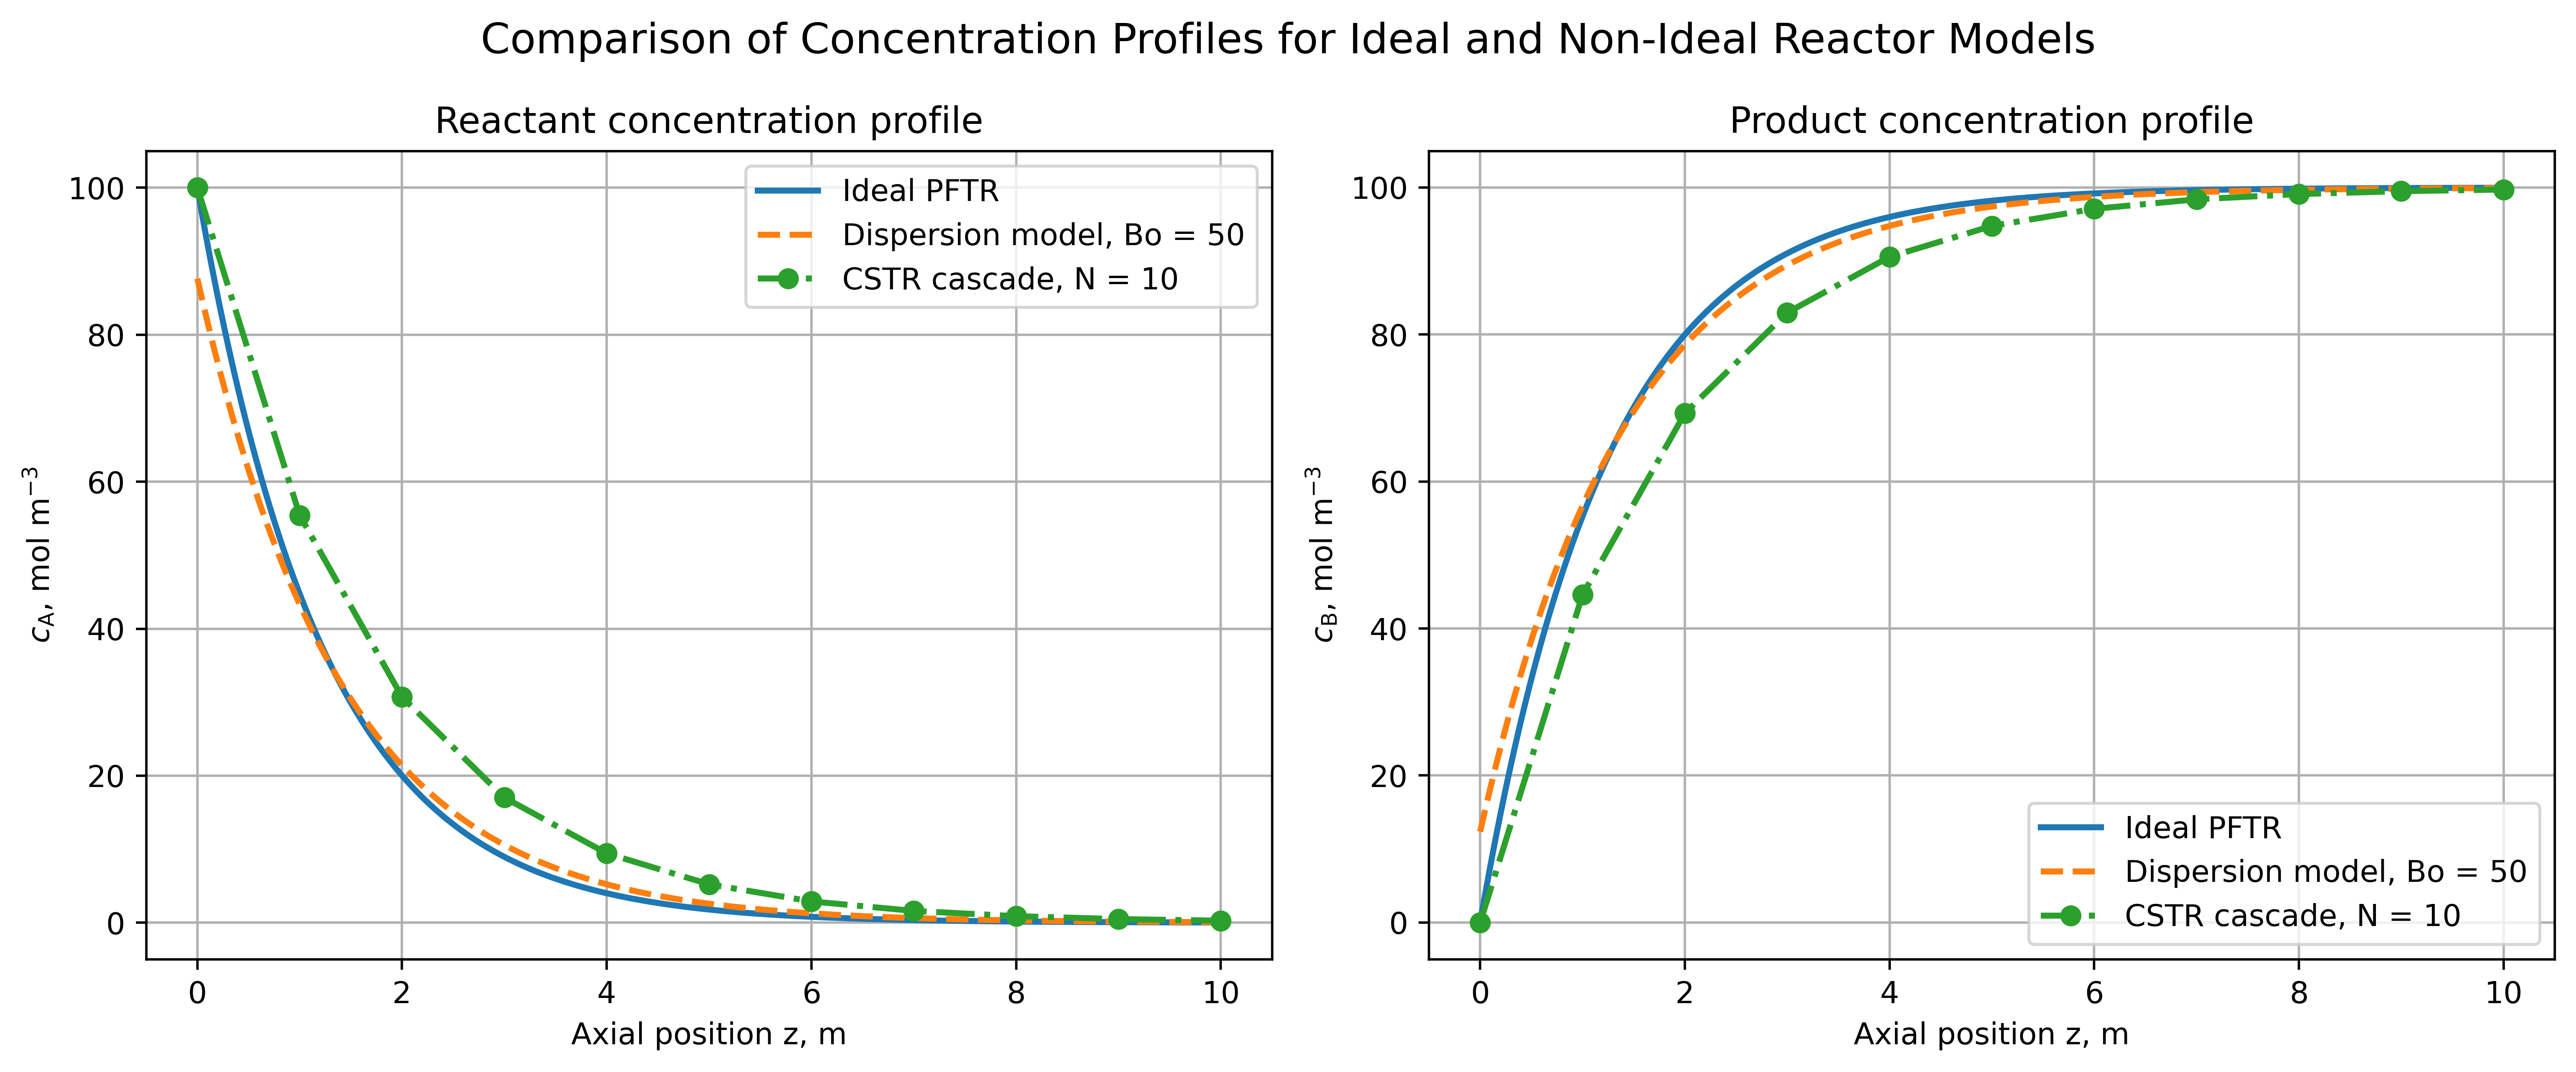

In [76]:
# Concentration profile comparison of ideal PFTR, non-ideal dispersion model and CSTR cascade

z_cascade = np.linspace(0.0, L, N_CSTR + 1)             # equivalent axial positions, m

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi = 500)

# Concentration profile of A
axes[0].plot(
    z_pftr,
    c_A_pftr,
    linewidth=2,
    label="Ideal PFTR"
)

axes[0].plot(
    z_disp,
    c_A_disp,
    linewidth=2,
    linestyle="--",
    label=f"Dispersion model, Bo = {Bo:.0f}"
)

axes[0].plot(
    z_cascade,
    c_A_cascade,
    marker="o",
    linestyle="-.",
    linewidth=2,
    label=f"CSTR cascade, N = {N_CSTR}"
)

axes[0].set_xlabel("Axial position z, m")
axes[0].set_ylabel(r"$c_{\mathrm{A}}$, mol m$^{-3}$")
axes[0].set_title("Reactant concentration profile")
axes[0].grid(True)
axes[0].legend()


# Concentration profile of B
axes[1].plot(
    z_pftr,
    c_B_pftr,
    linewidth=2,
    label="Ideal PFTR"
)

axes[1].plot(
    z_disp,
    c_B_disp,
    linewidth=2,
    linestyle="--",
    label=f"Dispersion model, Bo = {Bo:.0f}"
)

axes[1].plot(
    z_cascade,
    c_B_cascade,
    marker="o",
    linestyle="-.",
    linewidth=2,
    label=f"CSTR cascade, N = {N_CSTR}"
)

axes[1].set_xlabel("Axial position z, m")
axes[1].set_ylabel(r"$c_{\mathrm{B}}$, mol m$^{-3}$")
axes[1].set_title("Product concentration profile")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Comparison of Concentration Profiles for Ideal and Non-Ideal Reactor Models", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Residence time distribution

## 4.1 Ideal PFTR

For the ideal PFTR, axial backmixing is neglected. All fluid elements move through the reactor with the same residence time. Therefore, the residence time distribution is infinitely narrow and the cumulative distribution function changes from zero to one at the nominal residence time.

\begin{equation}
\tau = \frac{L}{u}
\tag{38}
\end{equation}

\begin{equation}
F(t) =
\left\{
\begin{array}{ll}
0, & t < \tau \\
1, & t > \tau
\end{array}
\right.
\tag{39}
\end{equation}

In dimensionless form, the residence time is expressed as:

\begin{equation}
\Theta = \frac{t}{\tau}
\tag{40}
\end{equation}

Thus, the ideal PFTR shows an instantaneous outlet response at $\Theta = 1$. This represents the limiting case without residence time spreading.

## 4.2 Residence Time Distribution of the Non-Ideal Tubular Reactor

For the non-ideal tubular reactor, the residence time distribution is calculated from the dynamic response of an inert tracer. Since the tracer does not react, the model contains only convective and dispersive transport. In this case, no reaction is undergoing. The dynamic axial dispersion balance is a partial differential equation:

\begin{equation}
\frac{\partial c_{\mathrm{T}}}{\partial t}
=
\mathcal{D} \frac{\partial^2 c_{\mathrm{T}}}{\partial z^2}
-
u \frac{\partial c_{\mathrm{T}}}{\partial z}
\tag{41}
\end{equation}

Eq. (41) cannot be solved directly with `solve_bvp`, because it contains derivatives with respect to both time and reactor length. Therefore, the time derivative is approximated by a backward finite difference:

\begin{equation}
\frac{\partial c_{\mathrm{T}}}{\partial t}
\approx
\frac{c_{\mathrm{T}}(t_i,z)-c_{\mathrm{T}}(t_{i-1},z)}{\Delta t}
\tag{42}
\end{equation}

Inserting Eq. (42) into Eq. (41) gives a boundary value problem in the axial coordinate $z$ for each time step. To solve this second-order equation with `solve_bvp`, it is rewritten as a first-order system:

\begin{equation}
\frac{\mathrm{d} c_{\mathrm{T}}}{\mathrm{d} z}
=
y
\tag{43}
\end{equation}

\begin{equation}
\frac{\mathrm{d} y}{\mathrm{d} z}
=
\frac{1}{\mathcal{D}}
\left(
\frac{c_{\mathrm{T}}(t_i,z)-c_{\mathrm{T}}(t_{i-1},z)}{\Delta t}
+
u y
\right)
\tag{44}
\end{equation}

The initial condition for the tracer concentration inside the reactor is:

\begin{equation}
c_{\mathrm{T}}(t=0,z) = 0
\tag{45}
\end{equation}

The inlet boundary condition is formulated as a Danckwerts condition. It balances the upstream convective tracer flow with the convective and dispersive transport at the reactor inlet:

\begin{equation}
\left.
\frac{\partial c_{\mathrm{T}}}{\partial z}
\right|_{z=0}
=
\frac{u A c_{\mathrm{T}}(0,t_i)-u_0 A_0 c_{\mathrm{T,in}}(t_i)}
{A \mathcal{D}}
\tag{46}
\end{equation}

At the reactor outlet, a zero-gradient condition is applied:

\begin{equation}
\left.
\frac{\partial c_{\mathrm{T}}}{\partial z}
\right|_{z=L}
=
0
\tag{47}
\end{equation}

The balance equations are implemented in the function `dispersion_model_tracer`, while the corresponding boundary conditions are implemented in the function `bc_tracer`. For every time step, the previous tracer concentration profile is used in Eq. (44), and the new profile is calculated by solving the resulting boundary value problem. The outlet tracer concentration is then used to determine the cumulative residence time distribution.

Now, the tracer inlet concentration is set to $1\; \mathrm{mol \; m^{-3}}$. The time discretization uses $250$ steps.

In [77]:
# Tracer RTD parameters for the axial dispersion model

c_T_in_step = 1.0                 # tracer inlet step concentration, mol m^-3

tau_tracer = L / u                # reactor space time used for tracer response, s
t_end_tracer = 5.0 * tau_tracer   # final tracer simulation time, s
n_time_tracer = 250               # number of time points, -

t_tracer = np.linspace(0.0, t_end_tracer, n_time_tracer)   # time grid, s
dt_tracer = t_tracer[1] - t_tracer[0]                      # constant time step, s

z_tracer = z_mesh.copy()          # axial grid for tracer BVP, m

print(f"c_T_in_step = {c_T_in_step:.2f} mol m^-3")
print(f"tau_tracer = {tau_tracer:.4f} s")
print(f"t_end_tracer = {t_end_tracer:.4f} s")
print(f"dt_tracer = {dt_tracer:.4e} s")
print(f"z nodes = {len(z_tracer)}")

c_T_in_step = 1.00 mol m^-3
tau_tracer = 8.0425 s
t_end_tracer = 40.2124 s
dt_tracer = 1.6150e-01 s
z nodes = 250


In [78]:
def dispersion_model_tracer(z, y, c_T_previous, z_previous, dt, u, D_ax):
    """
    Define the dynamic axial dispersion model for an inert tracer.

    The time derivative is approximated by a backward finite difference.
    For each time step, the resulting equation is solved as a BVP in z.

    State vector
    ------------
    y[0] = c_T
        Tracer concentration, mol m^-3.
    y[1] = dc_T/dz
        Axial tracer concentration gradient, mol m^-4.

    Inputs
    ------
    z : np.ndarray
        Axial reactor coordinate used by solve_bvp, m.
    y : np.ndarray
        State matrix with shape (2, len(z)).
    c_T_previous : np.ndarray
        Tracer concentration profile from the previous time step,
        mol m^-3.
    z_previous : np.ndarray
        Axial grid of the previous tracer profile, m.
    dt : float
        Time-step size, s.
    u : float
        Superficial velocity in the reactor, m s^-1.
    D_ax : float
        Axial dispersion coefficient, m^2 s^-1.

    Output
    ------
    dy_dz : np.ndarray
        Derivatives of the state vector with shape (2, len(z)).
        Rows are [dc_T/dz, d2c_T/dz2].
    """
    c_T = y[0]                                      # tracer concentration, mol m^-3
    dc_T_dz = y[1]                                  # tracer concentration gradient, mol m^-4

    c_T_old = np.interp(z, z_previous, c_T_previous)

    d2c_T_dz2 = ((c_T - c_T_old) / dt + u * dc_T_dz) / D_ax

    dy_dz = np.vstack((dc_T_dz, d2c_T_dz2))

    return dy_dz


def bc_tracer(ya, yb, c_T_in, u_0, A_0, u, A, D_ax):
    """
    Define the Danckwerts inlet boundary condition and the zero-gradient
    outlet boundary condition for the tracer dispersion model.

    Inputs
    ------
    ya : np.ndarray
        State vector at reactor inlet z = 0.
        ya = [c_T, dc_T/dz].
    yb : np.ndarray
        State vector at reactor outlet z = L.
        yb = [c_T, dc_T/dz].
    c_T_in : float
        Tracer inlet concentration in the upstream section, mol m^-3.
    u_0 : float
        Upstream superficial velocity, m s^-1.
    A_0 : float
        Upstream cross-sectional area, m^2.
    u : float
        Superficial velocity in the reactor, m s^-1.
    A : float
        Reactor cross-sectional area, m^2.
    D_ax : float
        Axial dispersion coefficient, m^2 s^-1.

    Output
    ------
    bc : np.ndarray
        Boundary-condition residuals [bc_in, bc_out].
        The BVP solver searches for bc = [0, 0].
    """
    bc_in = ya[1] - (u * A * ya[0] - u_0 * A_0 * c_T_in) / (A * D_ax)
    bc_out = yb[1]                                  # zero-gradient outlet, mol m^-4

    bc = np.array([bc_in, bc_out])

    return bc

The tracer dispersion model is solved on the defined time grid. For each time step, the previous tracer profile is used to approximate the time derivative and to provide the initial guess for the next boundary value problem. The resulting tracer concentration profile is stored as $c_{\mathrm{T}}(z,t_i)$.

The outlet tracer concentration is taken at the reactor outlet:

\begin{equation}
c_{\mathrm{T,out}}(t_i) = c_{\mathrm{T}}(L,t_i)
\tag{48}
\end{equation}

From the outlet response, the cumulative residence time distribution is calculated as:

\begin{equation}
F(t_i) = \frac{c_{\mathrm{T,out}}(t_i)}{c_{\mathrm{T,in}}}
\tag{49}
\end{equation}

The residence time distribution is obtained by numerical differentiation of the cumulative distribution:

\begin{equation}
E(t_i) \approx \frac{F(t_i)-F(t_{i-1})}{t_i-t_{i-1}}
\tag{50}
\end{equation}

For comparison between reactor models, the time axis is converted into the dimensionless residence time:

\begin{equation}
\Theta_i = \frac{t_i}{\tau}
\tag{51}
\end{equation}

The dimensionless RTD function is calculated by scaling $E(t)$ with the mean residence time:

\begin{equation}
E(\Theta_i) = \tau E(t_i)
\tag{52}
\end{equation}

The numerical quality of the RTD calculation is checked by integrating the E-function. For a correctly normalized residence time distribution, both integrals should approach one:

\begin{equation}
\int_0^\infty E(t) \ \mathrm{d}t \approx 1
\qquad
\int_0^\infty E(\Theta) \ \mathrm{d}\Theta \approx 1
\tag{53}
\end{equation}

The final value of $F(t)$ should also approach one, because a step tracer input with constant inlet concentration eventually leads to the same tracer concentration at the reactor outlet.

In [79]:
# Solve tracer dispersion model and calculate F- and E-functions
# Uses variables already defined in this notebook:
# t_tracer, n_time_tracer, z_tracer, dt_tracer, c_T_in_step, tau_tracer
# u, u_0, A, A_0, D_ax, tol_bvp, max_nodes_bvp

c_T_profiles = np.zeros((n_time_tracer, z_tracer.size))      # tracer profiles, mol m^-3
dc_T_dz_profiles = np.zeros((n_time_tracer, z_tracer.size))  # tracer gradients, mol m^-4
c_T_out_disp = np.zeros(n_time_tracer)                       # outlet tracer concentration, mol m^-3

# Initial tracer profile inside the reactor
c_T_previous = np.zeros_like(z_tracer)                       # initial c_T(z,0), mol m^-3

# Initial BVP guess
y_guess = np.zeros((2, z_tracer.size))
y_guess[0, :] = c_T_previous                                # c_T guess, mol m^-3
y_guess[1, :] = 0.0                                         # dc_T/dz guess, mol m^-4

for i, t_i in enumerate(t_tracer):
    c_T_in_current = c_T_in_step                            # step input, mol m^-3

    sol_tracer = solve_bvp(
        fun=lambda z, y: dispersion_model_tracer(
            z, y, c_T_previous, z_tracer, dt_tracer, u, D_ax
        ),
        bc=lambda ya, yb: bc_tracer(
            ya, yb, c_T_in_current, u_0, A_0, u, A, D_ax
        ),
        x=z_tracer,
        y=y_guess,
        tol=tol_bvp,
        max_nodes=max_nodes_bvp,
    )

    if not sol_tracer.success:
        raise RuntimeError(f"Tracer BVP failed at t = {t_i:.4f} s: {sol_tracer.message}")

    y_current = sol_tracer.sol(z_tracer)

    c_T_profiles[i, :] = y_current[0]
    dc_T_dz_profiles[i, :] = y_current[1]
    c_T_out_disp[i] = y_current[0, -1]

    # Use current solution as previous profile and next initial guess
    c_T_previous = y_current[0].copy()
    y_guess = y_current.copy()

# Dimensional F- and E-functions
F_t_disp = c_T_out_disp / c_T_in_step                       # cumulative RTD function, -
E_t_disp = np.gradient(F_t_disp, t_tracer)                  # RTD function, s^-1

# Dimensionless F- and E-functions
theta_disp = t_tracer / tau_tracer                          # dimensionless time, -
F_theta_disp = F_t_disp                                     # dimensionless cumulative RTD, -
E_theta_disp = tau_tracer * E_t_disp                        # dimensionless RTD, -

# Numerical checks
area_E_t = np.trapezoid(E_t_disp, t_tracer)                     # integral of E(t), -
area_E_theta = np.trapezoid(E_theta_disp, theta_disp)           # integral of E(theta), -

print(f"Final F(t) = {F_t_disp[-1]:.5f}")
print(f"Integral E(t) dt = {area_E_t:.5f}")
print(f"Integral E(theta) dtheta = {area_E_theta:.5f}")
print(f"Outlet tracer concentration = {c_T_out_disp[-1]:.5f} mol m^-3")

Final F(t) = 1.00000
Integral E(t) dt = 1.00000
Integral E(theta) dtheta = 1.00000
Outlet tracer concentration = 1.00000 mol m^-3


## 4.3 Residence Time Distribution in a CSTR and CSTR Cascade

The residence time distribution of the ideal CSTR and the CSTR cascade is calculated from the dynamic response to an inert step tracer. The tracer does not react and is only transported by the liquid flow through the ideally mixed vessels. First, the outlet tracer concentration is calculated with `solve_ivp`. The F- and E-functions are then obtained from the normalized outlet response.

For one ideal CSTR, the tracer balance is:

\begin{equation}
\frac{\mathrm{d} c_{\mathrm{T}}}{\mathrm{d} t}
=
\frac{c_{\mathrm{T,in}} - c_{\mathrm{T}}}{\tau}
\tag{54}
\end{equation}

For a cascade of $N$ ideal CSTRs, the total residence time is divided equally between all tanks:

\begin{equation}
\tau_N = \frac{\tau}{N}
\tag{55}
\end{equation}

The tracer balances for the cascade are:

\begin{equation}
\frac{\mathrm{d} c_{\mathrm{T},1}}{\mathrm{d} t}
=
\frac{c_{\mathrm{T,in}} - c_{\mathrm{T},1}}{\tau_N}
\qquad
\frac{\mathrm{d} c_{\mathrm{T},m}}{\mathrm{d} t}
=
\frac{c_{\mathrm{T},m-1} - c_{\mathrm{T},m}}{\tau_N}
\quad m = 2,\dots,N
\tag{56}
\end{equation}

The outlet tracer concentration of the last vessel is used to calculate the cumulative residence time distribution:

\begin{equation}
F(t) = \frac{c_{\mathrm{T,out}}(t)}{c_{\mathrm{T,in}}}
\tag{57}
\end{equation}

The E-function is obtained by numerical differentiation:

\begin{equation}
E(t) = \frac{\mathrm{d}F(t)}{\mathrm{d}t}
\tag{58}
\end{equation}

The dimensionless functions are calculated with:

\begin{equation}
\Theta = \frac{t}{\tau}
\qquad
E(\Theta) = \tau E(t)
\tag{59}
\end{equation}

For $N=1$, the cascade corresponds to one ideal CSTR. With increasing $N$, the residence time distribution becomes narrower and approaches ideal PFTR behaviour.

In [80]:
# Residence time distribution of one ideal CSTR

c_T_in_cstr = 1.0                    # tracer inlet step concentration, mol m^-3
tau_total_rtd = L / u                # total mean residence time, s

t_end_cstr = 8.0 * tau_total_rtd     # final simulation time, s
n_time_cstr = 500                    # number of time points, -
t_cstr = np.linspace(0.0, t_end_cstr, n_time_cstr)

def cstr_tracer_model(t, c_T):
    """
    Dynamic tracer balance for one ideal CSTR.

    Input
    -----
    t : float
        Time, s.
    c_T : np.ndarray
        Tracer concentration in the CSTR, mol m^-3.

    Output
    ------
    dc_T_dt : list
        Time derivative of tracer concentration, mol m^-3 s^-1.
    """
    dc_T_dt = (c_T_in_cstr - c_T[0]) / tau_total_rtd
    return [dc_T_dt]


sol_cstr_rtd = solve_ivp(
    fun=cstr_tracer_model,
    t_span=(t_cstr[0], t_cstr[-1]),
    y0=[0.0],
    t_eval=t_cstr,
    rtol=rtol_ivp,
    atol=atol_ivp,
)

if not sol_cstr_rtd.success:
    raise RuntimeError(sol_cstr_rtd.message)

# F- and E-functions
c_T_out_cstr = sol_cstr_rtd.y[0]                         # outlet tracer concentration, mol m^-3

F_t_cstr = c_T_out_cstr / c_T_in_cstr                    # cumulative RTD function, -
E_t_cstr = np.gradient(F_t_cstr, t_cstr)                 # RTD function, s^-1

theta_cstr = t_cstr / tau_total_rtd                      # dimensionless time, -
F_theta_cstr = F_t_cstr                                  # dimensionless cumulative RTD, -
E_theta_cstr = tau_total_rtd * E_t_cstr                  # dimensionless RTD, -

# Numerical checks
area_E_t_cstr = np.trapezoid(E_t_cstr, t_cstr)
area_E_theta_cstr = np.trapezoid(E_theta_cstr, theta_cstr)

print(f"CSTR final F(t) = {F_t_cstr[-1]:.5f}")
print(f"CSTR integral E(t) dt = {area_E_t_cstr:.5f}")
print(f"CSTR integral E(theta) dtheta = {area_E_theta_cstr:.5f}")
print(f"CSTR outlet tracer concentration = {c_T_out_cstr[-1]:.5f} mol m^-3")

CSTR final F(t) = 0.99966
CSTR integral E(t) dt = 0.99966
CSTR integral E(theta) dtheta = 0.99966
CSTR outlet tracer concentration = 0.99966 mol m^-3


In [81]:
# Residence time distribution of a CSTR cascade

N_cascade_rtd = N_CSTR                       # number of CSTRs in cascade, -
tau_tank_rtd = tau_total_rtd / N_cascade_rtd # residence time per tank, s

t_end_cascade = 8.0 * tau_total_rtd          # final simulation time, s
n_time_cascade = 500                         # number of time points, -
t_cascade = np.linspace(0.0, t_end_cascade, n_time_cascade)

def cstr_cascade_tracer_model(t, c_T):
    """
    Dynamic tracer balances for a CSTR cascade.

    Input
    -----
    t : float
        Time, s.
    c_T : np.ndarray
        Tracer concentrations in all tanks, mol m^-3.

    Output
    ------
    dc_T_dt : np.ndarray
        Time derivatives of tracer concentrations, mol m^-3 s^-1.
    """
    dc_T_dt = np.zeros_like(c_T)

    dc_T_dt[0] = (c_T_in_cstr - c_T[0]) / tau_tank_rtd

    for m in range(1, N_cascade_rtd):
        dc_T_dt[m] = (c_T[m - 1] - c_T[m]) / tau_tank_rtd

    return dc_T_dt


sol_cascade_rtd = solve_ivp(
    fun=cstr_cascade_tracer_model,
    t_span=(t_cascade[0], t_cascade[-1]),
    y0=np.zeros(N_cascade_rtd),
    t_eval=t_cascade,
    rtol=rtol_ivp,
    atol=atol_ivp,
)

if not sol_cascade_rtd.success:
    raise RuntimeError(sol_cascade_rtd.message)

# F- and E-functions
c_T_out_cascade = sol_cascade_rtd.y[-1]                  # outlet tracer concentration, mol m^-3

F_t_cascade = c_T_out_cascade / c_T_in_cstr              # cumulative RTD function, -
E_t_cascade = np.gradient(F_t_cascade, t_cascade)        # RTD function, s^-1

theta_cascade = t_cascade / tau_total_rtd                # dimensionless time, -
F_theta_cascade = F_t_cascade                            # dimensionless cumulative RTD, -
E_theta_cascade = tau_total_rtd * E_t_cascade            # dimensionless RTD, -

# Numerical checks
area_E_t_cascade = np.trapezoid(E_t_cascade, t_cascade)
area_E_theta_cascade = np.trapezoid(E_theta_cascade, theta_cascade)

print(f"CSTR cascade final F(t) = {F_t_cascade[-1]:.5f}")
print(f"CSTR cascade integral E(t) dt = {area_E_t_cascade:.5f}")
print(f"CSTR cascade integral E(theta) dtheta = {area_E_theta_cascade:.5f}")
print(f"CSTR cascade outlet tracer concentration = {c_T_out_cascade[-1]:.5f} mol m^-3")

CSTR cascade final F(t) = 1.00000
CSTR cascade integral E(t) dt = 1.00000
CSTR cascade integral E(theta) dtheta = 1.00000
CSTR cascade outlet tracer concentration = 1.00000 mol m^-3


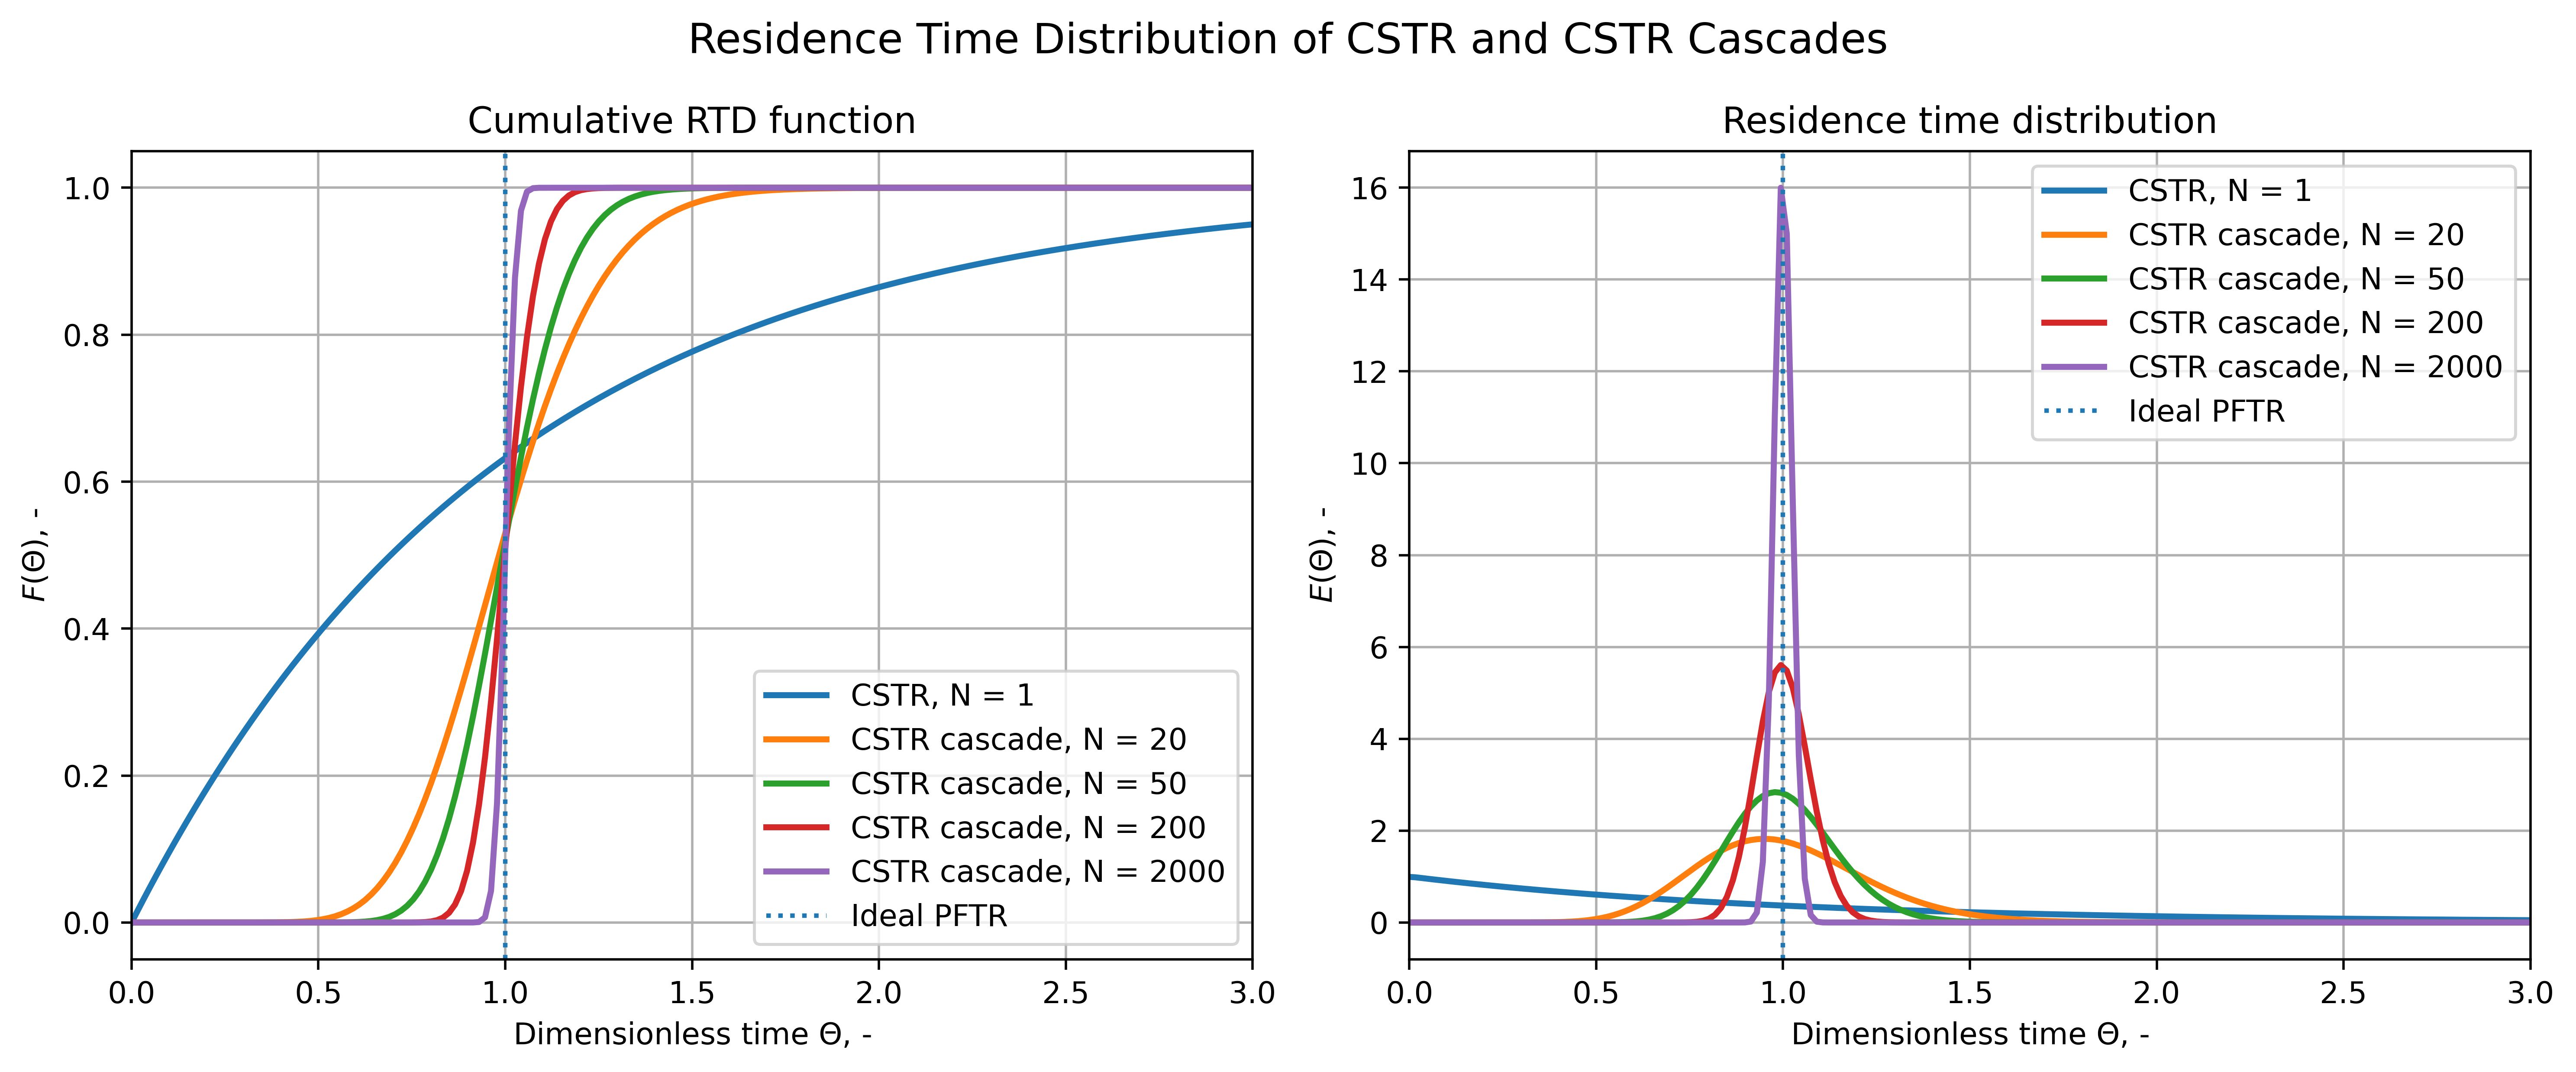

In [82]:
# Plot RTD functions for one CSTR and CSTR cascades with different N

N_cascade_values = [20, 50, 200, 2000]                 # number of tanks in cascade, -
cascade_rtd_results = {}

for N_i in N_cascade_values:
    tau_tank_i = tau_total_rtd / N_i             # residence time per tank, s

    def cstr_cascade_tracer_model_N(t, c_T):
        dc_T_dt = np.zeros_like(c_T)
        dc_T_dt[0] = (c_T_in_cstr - c_T[0]) / tau_tank_i

        for m in range(1, N_i):
            dc_T_dt[m] = (c_T[m - 1] - c_T[m]) / tau_tank_i

        return dc_T_dt

    sol_cascade_i = solve_ivp(
        fun=cstr_cascade_tracer_model_N,
        t_span=(t_cascade[0], t_cascade[-1]),
        y0=np.zeros(N_i),
        t_eval=t_cascade,
        rtol=rtol_ivp,
        atol=atol_ivp,
    )

    if not sol_cascade_i.success:
        raise RuntimeError(f"CSTR cascade failed for N = {N_i}: {sol_cascade_i.message}")

    c_T_out_i = sol_cascade_i.y[-1]              # outlet tracer concentration, mol m^-3

    F_t_i = c_T_out_i / c_T_in_cstr              # cumulative RTD function, -
    E_t_i = np.gradient(F_t_i, t_cascade)        # RTD function, s^-1

    theta_i = t_cascade / tau_total_rtd          # dimensionless time, -
    F_theta_i = F_t_i                            # dimensionless cumulative RTD, -
    E_theta_i = tau_total_rtd * E_t_i            # dimensionless RTD, -

    cascade_rtd_results[N_i] = {
        "theta": theta_i,
        "F_theta": F_theta_i,
        "E_theta": E_theta_i,
    }


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=500)

# F-functions
axes[0].plot(theta_cstr, F_theta_cstr, linewidth=2, label="CSTR, N = 1")

for N_i in N_cascade_values:
    axes[0].plot(
        cascade_rtd_results[N_i]["theta"],
        cascade_rtd_results[N_i]["F_theta"],
        linewidth=2,
        label=f"CSTR cascade, N = {N_i}",
    )

axes[0].axvline(1.0, linestyle=":", linewidth=1.5, label="Ideal PFTR")
axes[0].set_xlabel(r"Dimensionless time $\Theta$, -")
axes[0].set_ylabel(r"$F(\Theta)$, -")
axes[0].set_title("Cumulative RTD function")
axes[0].set_xlim(0.0, 3.0)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True)
axes[0].legend()


# E-functions
axes[1].plot(theta_cstr, E_theta_cstr, linewidth=2, label="CSTR, N = 1")

for N_i in N_cascade_values:
    axes[1].plot(
        cascade_rtd_results[N_i]["theta"],
        cascade_rtd_results[N_i]["E_theta"],
        linewidth=2,
        label=f"CSTR cascade, N = {N_i}",
    )

axes[1].axvline(1.0, linestyle=":", linewidth=1.5, label="Ideal PFTR")
axes[1].set_xlabel(r"Dimensionless time $\Theta$, -")
axes[1].set_ylabel(r"$E(\Theta)$, -")
axes[1].set_title("Residence time distribution")
axes[1].set_xlim(0.0, 3.0)
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Residence Time Distribution of CSTR and CSTR Cascades", fontsize=14)
fig.tight_layout()
plt.show()

## 4.4 Validation

Before the parameter studies are evaluated, the implemented reactor models are checked with two validation steps. First, the component mass balance is tested for the reaction $\mathrm{A} \rightarrow \mathrm{B}$. Since the reaction is stoichiometrically one-to-one and no volume change is considered, the sum of both component concentrations must remain constant.

Second, the axial dispersion model is compared with the ideal PFTR model at a high Bodenstein number. For large $Bo$, axial dispersion becomes negligible and the dispersion model must approach the ideal plug-flow solution. This provides a numerical consistency check between the boundary value problem and the initial value problem.

### 4.4.1 Mass Balance Validation

For the irreversible reaction $\mathrm{A} \rightarrow \mathrm{B}$, one mole of component $\mathrm{A}$ is converted into one mole of component $\mathrm{B}$. Therefore, the total concentration must remain constant along the reactor if density and volumetric flow rate are constant.

\begin{equation}
c_{\mathrm{tot}}(z) = c_{\mathrm{A}}(z) + c_{\mathrm{B}}(z)
\tag{60}
\end{equation}

The reference value is given by the inlet concentration sum:

\begin{equation}
c_{\mathrm{tot},0} = c_{\mathrm{A},0} + c_{\mathrm{B},0}
\tag{61}
\end{equation}

The maximum relative mass balance deviation is calculated as:

\begin{equation}
\varepsilon_{\mathrm{MB}} =
\frac{
\max \left| c_{\mathrm{tot}}(z) - c_{\mathrm{tot},0} \right|
}{
c_{\mathrm{tot},0}
}
\tag{62}
\end{equation}

For the CSTR cascade, the same validation is applied to the outlet concentration of each tank:

\begin{equation}
\varepsilon_{\mathrm{MB,cascade}} =
\frac{
\max \left| c_{\mathrm{A},m} + c_{\mathrm{B},m} - c_{\mathrm{tot},0} \right|
}{
c_{\mathrm{tot},0}
}
\qquad m = 1,\dots,N
\tag{63}
\end{equation}

Small values of $\varepsilon_{\mathrm{MB}}$ indicate that the numerical implementation conserves the total amount of material and that the stoichiometric source terms are implemented consistently.

In [83]:
def mass_balance_deviation(c_A, c_B, c_tot_0):
    """
    Calculate the maximum relative mass balance deviation for A -> B.

    Inputs
    ------
    c_A : np.ndarray
        Concentration profile or concentration vector of A, mol m^-3.
    c_B : np.ndarray
        Concentration profile or concentration vector of B, mol m^-3.
    c_tot_0 : float
        Reference total inlet concentration, mol m^-3.

    Output
    ------
    eps_MB : float
        Maximum relative mass balance deviation, -.
    """
    c_tot = c_A + c_B                                  # total concentration, mol m^-3
    eps_MB = np.max(np.abs(c_tot - c_tot_0)) / c_tot_0 # relative deviation, -

    return eps_MB


# Reference total inlet concentration
c_tot_0 = np.sum(c_in)                                 # inlet total concentration, mol m^-3

# PFTR mass balance validation
eps_MB_pftr = mass_balance_deviation(
    c_A=c_A_pftr,
    c_B=c_B_pftr,
    c_tot_0=c_tot_0,
)

# Axial dispersion model mass balance validation
eps_MB_disp = mass_balance_deviation(
    c_A=c_A_disp,
    c_B=c_B_disp,
    c_tot_0=c_tot_0,
)

# CSTR cascade mass balance validation
# Row 0 is the feed, rows 1...N_CSTR are the CSTR outlets.
eps_MB_cascade = mass_balance_deviation(
    c_A=c_cascade[1:, 0],
    c_B=c_cascade[1:, 1],
    c_tot_0=c_tot_0,
)

print("Mass balance validation")
print(f"Reference c_tot,0 = {c_tot_0:.6f} mol m^-3")
print(f"PFTR:                 eps_MB = {eps_MB_pftr:.3e}")
print(f"Dispersion model:     eps_MB = {eps_MB_disp:.3e}")
print(f"CSTR cascade:         eps_MB = {eps_MB_cascade:.3e}")

Mass balance validation
Reference c_tot,0 = 100.000000 mol m^-3
PFTR:                 eps_MB = 8.527e-16
Dispersion model:     eps_MB = 2.842e-16
CSTR cascade:         eps_MB = 2.842e-16


### 4.4.2 Validation of Dispersion Model at High Bodenstein Number with PFTR

The axial dispersion model should approach the ideal PFTR for high Bodenstein numbers. This follows directly from the definition of the axial dispersion coefficient:

\begin{equation}
\mathcal{D} = \frac{uL}{Bo}
\tag{64}
\end{equation}

For $Bo \rightarrow \infty$, the axial dispersion coefficient approaches zero and the dispersive term in the material balance becomes negligible:

\begin{equation}
\mathcal{D} \frac{\mathrm{d}^{2} c_i}{\mathrm{d} z^{2}} \rightarrow 0
\tag{65}
\end{equation}

The dispersion balance then approaches the ideal PFTR balance:

\begin{equation}
u \frac{\mathrm{d} c_i}{\mathrm{d} z}
=
\sum_j \nu_{i,j} r_j
\tag{66}
\end{equation}

In this case, the Bodenstein number was set to $Bo = \mathrm{10000}$.

To validate the boundary value implementation, the dispersion model is solved at a high Bodenstein number and compared with the ideal PFTR initial value solution. The concentration profile errors are calculated as:

\begin{equation}
\varepsilon_{c_{\mathrm{A}}} =
\frac{
\max \left| c_{\mathrm{A,disp}}(z) - c_{\mathrm{A,PFTR}}(z) \right|
}{
c_{\mathrm{A},0}
}
\tag{67}
\end{equation}

\begin{equation}
\varepsilon_{c_{\mathrm{B}}} =
\frac{
\max \left| c_{\mathrm{B,disp}}(z) - c_{\mathrm{B,PFTR}}(z) \right|
}{
c_{\mathrm{A},0}
}
\tag{68}
\end{equation}

The outlet conversion difference is calculated as:

\begin{equation}
\varepsilon_X =
\left| X_{\mathrm{A,disp}} - X_{\mathrm{A,PFTR}} \right|
\tag{69}
\end{equation}

A small concentration error and a small conversion difference confirm that the dispersion model correctly reproduces the PFTR limit at sufficiently high $Bo$.

In [84]:
# Validation of the dispersion model against the PFTR limit at high Bodenstein number

Bo_validation = 1.0e4                         # high Bodenstein number for validation, -
D_ax_validation = u * L / Bo_validation       # axial dispersion coefficient, m^2 s^-1

# Independent initial guess for the BVP solver
c_A_guess_validation = np.linspace(c_in[0], c_A_pftr[-1], z_mesh.size)   # mol m^-3
c_B_guess_validation = c_in[0] - c_A_guess_validation                    # mol m^-3

dc_A_dz_guess_validation = np.gradient(c_A_guess_validation, z_mesh)     # mol m^-4
dc_B_dz_guess_validation = np.gradient(c_B_guess_validation, z_mesh)     # mol m^-4

y_guess_validation = np.vstack((
    c_A_guess_validation,
    dc_A_dz_guess_validation,
    c_B_guess_validation,
    dc_B_dz_guess_validation,
))

# Solve dispersion model at high Bo
sol_disp_validation = solve_bvp(
    fun=lambda z, y: dispersion_model(
        z=z,
        y=y,
        k=k,
        n=n,
        stoich_coeff=stoich_coeff,
        u=u,
        D_ax=D_ax_validation,
    ),
    bc=lambda ya, yb: dispersion_boundary_conditions(
        ya=ya,
        yb=yb,
        c_in=c_in,
        u_0=u_0,
        A_0=A_0,
        u=u,
        A=A,
        D_ax=D_ax_validation,
    ),
    x=z_mesh,
    y=y_guess_validation,
    tol=tol_bvp,
    max_nodes=max_nodes_bvp,
)

if not sol_disp_validation.success:
    raise RuntimeError(sol_disp_validation.message)

# Evaluate both models on the same axial grid
z_validation = z_eval

c_disp_validation = sol_disp_validation.sol(z_validation)
c_A_disp_validation = c_disp_validation[0]        # mol m^-3
c_B_disp_validation = c_disp_validation[2]        # mol m^-3

c_A_pftr_validation = np.interp(z_validation, z_pftr, c_A_pftr)
c_B_pftr_validation = np.interp(z_validation, z_pftr, c_B_pftr)

# Concentration-profile errors
eps_c_A = np.max(np.abs(c_A_disp_validation - c_A_pftr_validation)) / c_A_in
eps_c_B = np.max(np.abs(c_B_disp_validation - c_B_pftr_validation)) / c_A_in

# Outlet conversion difference
X_A_disp_validation = 1.0 - c_A_disp_validation[-1] / c_A_in
X_A_pftr_validation = 1.0 - c_A_pftr_validation[-1] / c_A_in

eps_X = np.abs(X_A_disp_validation - X_A_pftr_validation)

print("High-Bo validation of dispersion model")
print(f"Bo_validation = {Bo_validation:.2e}")
print(f"D_ax_validation = {D_ax_validation:.4e} m^2 s^-1")
print(f"PFTR outlet conversion:       X_A = {X_A_pftr_validation:.8f}")
print(f"Dispersion outlet conversion: X_A = {X_A_disp_validation:.8f}")
print(f"eps_c_A = {eps_c_A:.3e}")
print(f"eps_c_B = {eps_c_B:.3e}")
print(f"eps_X = {eps_X:.3e}")
print(f"BVP iterations = {sol_disp_validation.niter}")
print(f"BVP mesh nodes = {sol_disp_validation.x.size}")

High-Bo validation of dispersion model
Bo_validation = 1.00e+04
D_ax_validation = 1.2434e-03 m^2 s^-1
PFTR outlet conversion:       X_A = 0.99967849
Dispersion outlet conversion: X_A = 0.99967641
eps_c_A = 8.030e-04
eps_c_B = 8.030e-04
eps_X = 2.083e-06
BVP iterations = 8
BVP mesh nodes = 456


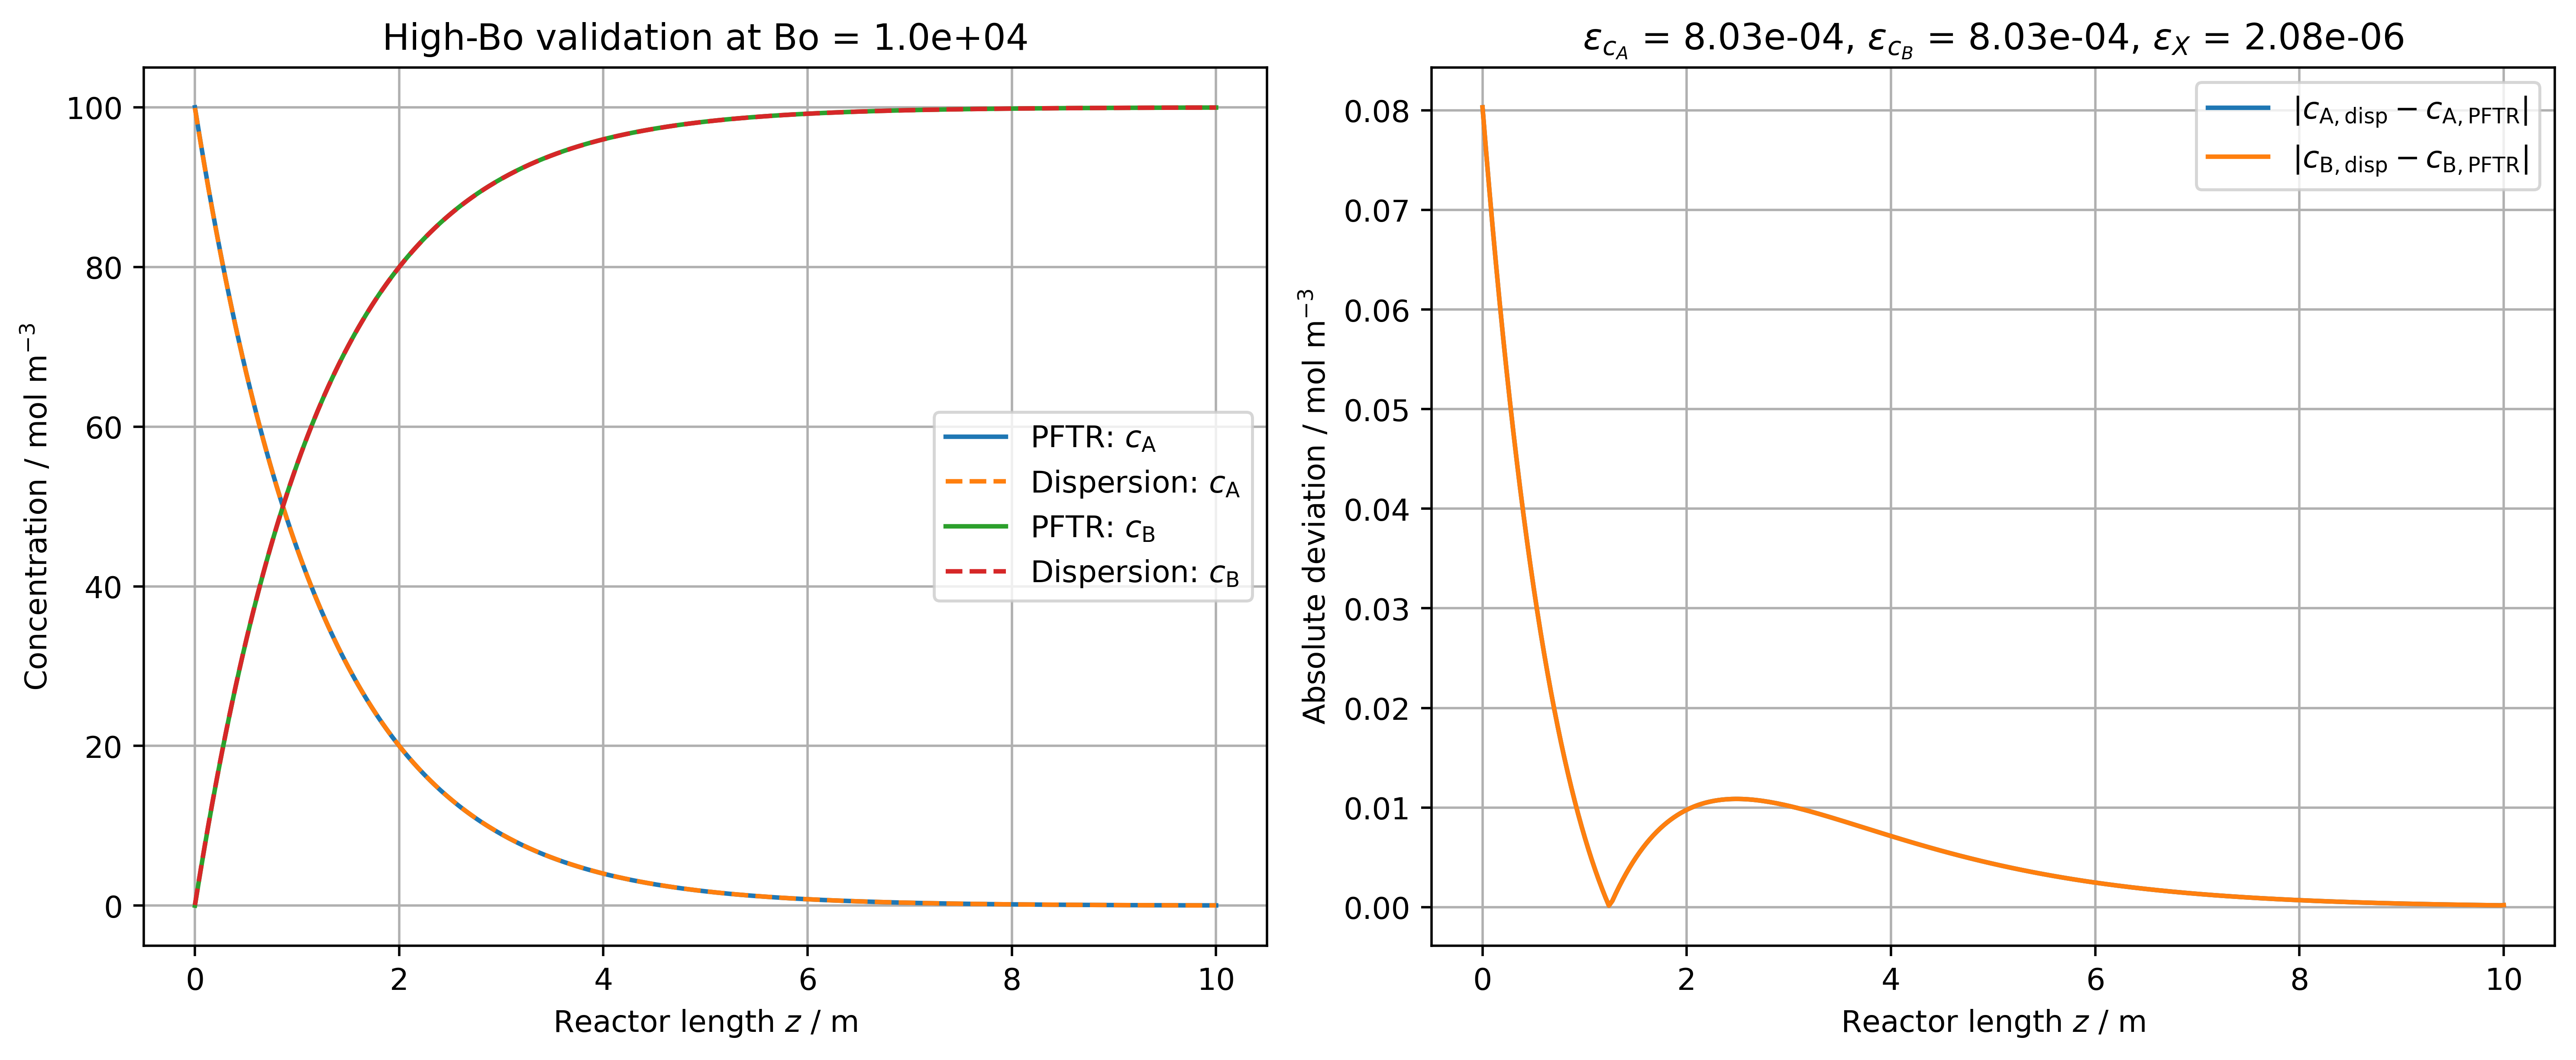

In [86]:
# Plot validation of the dispersion model against the PFTR limit at high Bodenstein number

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=500)

# Concentration profiles
axes[0].plot(z_validation, c_A_pftr_validation, label="PFTR: $c_{\\mathrm{A}}$")
axes[0].plot(z_validation, c_A_disp_validation, "--", label="Dispersion: $c_{\\mathrm{A}}$")
axes[0].plot(z_validation, c_B_pftr_validation, label="PFTR: $c_{\\mathrm{B}}$")
axes[0].plot(z_validation, c_B_disp_validation, "--", label="Dispersion: $c_{\\mathrm{B}}$")

axes[0].set_xlabel("Reactor length $z$ / m")
axes[0].set_ylabel("Concentration / mol m$^{-3}$")
axes[0].set_title(f"High-Bo validation at Bo = {Bo_validation:.1e}")
axes[0].grid(True)
axes[0].legend()

# Absolute profile deviations
axes[1].plot(
    z_validation,
    np.abs(c_A_disp_validation - c_A_pftr_validation),
    label="$|c_{\\mathrm{A,disp}} - c_{\\mathrm{A,PFTR}}|$",
)
axes[1].plot(
    z_validation,
    np.abs(c_B_disp_validation - c_B_pftr_validation),
    label="$|c_{\\mathrm{B,disp}} - c_{\\mathrm{B,PFTR}}|$",
)

axes[1].set_xlabel("Reactor length $z$ / m")
axes[1].set_ylabel("Absolute deviation / mol m$^{-3}$")
axes[1].set_title(
    f"$\\varepsilon_{{c_A}}$ = {eps_c_A:.2e}, "
    f"$\\varepsilon_{{c_B}}$ = {eps_c_B:.2e}, "
    f"$\\varepsilon_X$ = {eps_X:.2e}"
)
axes[1].grid(True)
axes[1].legend()

fig.tight_layout()
plt.show()

<!-- Markdown cell: Literature -->

## Literature

| No. | Source |
|---:|---|
| [1] | [Author(s). *Title*. Journal/Book, year, volume, pages. DOI or URL.] |
| [2] | [Author(s). *Title*. Journal/Book, year, volume, pages. DOI or URL.] |
| [3] | [Author(s). *Title*. Journal/Book, year, volume, pages. DOI or URL.] |

<!-- Markdown cell: Contribution -->

## Contribution

All group members contributed equally to the assignment.

Alternatively, if contributions were divided:

| Group member | Contribution |
|---|---|
| [Name 1] | [model derivation / implementation / plots / discussion / proofreading] |
| [Name 2] | [model derivation / implementation / plots / discussion / proofreading] |
| [Name 3] | [model derivation / implementation / plots / discussion / proofreading] |

<!-- Markdown cell: AI use and reflection -->

## AI Use and Reflection

### Tools Used

The following AI tools were used during the preparation of this assignment:

| Tool | Model / Version | Date of Use | Purpose |
|---|---|---:|---|
| ChatGPT | GPT-5.5 Thinking | June 2026 | Markdown formatting, language polishing, coding assistance, debugging support |
| GitHub Copilot | [version if used] | [date] | [purpose if used] |

### Areas of Use

AI tools were used for the following subtasks:

| Area | Use of AI | Own follow-up / verification |
|---|---|---|
| Markdown formatting | Formatting of report text, equations, tables, and captions | Manual proofreading and correction before insertion into the notebook |
| Language editing | Improvement of grammar, spelling, and readability | Scientific meaning was checked manually after editing |
| Code assistance | Support for implementation and debugging after the model equations were defined | Results were checked using units, limiting cases, and independent recalculation |
| Verification strategy | Suggestions for plausibility checks and limiting cases | Only checks considered physically meaningful were applied |

### Prompting Strategy

For language and Markdown editing, the scientific content was first written manually. The text was then provided to the AI tool with the instruction to improve grammar, readability, Markdown formatting, and equation notation without changing the scientific meaning.

For coding support, the model equations, parameters, and intended outputs were provided explicitly. The AI tool was asked for implementation support only after the mathematical model had been defined. Code suggestions were not used directly without inspection. The implemented code was checked manually against the model equations and verified by numerical plausibility checks.

### Critical Examination

The AI outputs were checked using the following methods:

| AI-supported task | Verification method | Result of verification |
|---|---|---|
| Markdown and language editing | Manual comparison with original scientific meaning | [to be added] |
| Code implementation | Unit checks, sign checks, limiting cases, and reproducibility checks | [to be added] |
| Literature or data suggestions | Independent verification against primary sources or authoritative databases | [to be added] |

Specific errors or unreliable outputs encountered during AI use are listed below:

| Error or issue | Correction |
|---|---|
| [to be added] | [to be added] |

### Statement of Own Contribution

The assumptions, verification strategy, scientific discussion, and engineering conclusions are the independent work of the authors. AI tools were used only as supporting tools for formatting, language improvement, debugging, and implementation assistance. The final interpretation of the numerical results was performed by the authors.

<!-- Markdown cell: Appendix -->

# X. Appendix

## X.X Python Packages and Function Documentation

All Python packages and implemented functions used in the program are listed below. The packages are used for numerical calculations, solving equations, creating plots, formatting tables, and documenting the results.

#### Used Python Packages

| Package / function | Purpose in the program |
|---|---|
| `numpy` as `np` | Numerical arrays, mathematical operations, and grid generation |
| `pandas` as `pd` | Creation and formatting of result tables |
| `matplotlib.pyplot` as `plt` | Creation of plots and figures |
| `solve_ivp` from `scipy.integrate` | Solution of ordinary differential equation systems |
| `[additional package]` | [purpose] |

#### Implemented Python Functions

| Function | Purpose |
|---|---|
| `[function_name(arguments)]` | [short description] |
| `[function_name(arguments)]` | [short description] |
| `[function_name(arguments)]` | [short description] |

#### General Implementation Note

The code was written to keep the model equations, parameter definitions, solver calls, and post-processing steps separated. This improves readability and allows individual parts of the implementation to be checked independently.